#### Uključivanje potrebnih biblioteka
- Biblioteka pandas - omogućava nam rad sad dataset-om (mogućnost čitanja, pisanja, modifikacije i sl.)
- Biblioteka numpy - omogućava nam rad sa matematičkim funkcijama, nizovima, listama i sl.
- Bibilioteka matplotlib.pyplot - omogućava nam crtanje grafikona
- Bibilioteka seaborn - omogućava nam detaljnije i naprednije crtanje grafika za analizu

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [3]:
from scipy.stats import shapiro, mannwhitneyu, norm
import statistics

# Uključivanje dataset-a i njegov opis (Faza 1)
- Link: https://www.kaggle.com/datasets/fedesoriano/air-quality-data-set?resource=download&select=AirQuality.csv
- Opis: 
    - Dataset sadrži podatke dobijene od senzora zagadjenosti vazduha postavljenog u Italijanskom gradu od 2004. do 2005. godine
    - Kolone:
        - Datum (DD/MM/YYYY)
        - Vreme (HH.MM.SS)
        - Tačna jednočasovna prosečna koncentracija CO u mg/m³
        - PT08.S1 (kalaj-oksid) – prosečan jednočasovni odziv senzora (nominalno cilja CO)
        - Tačna jednočasovna prosečna koncentracija nemetanskih ugljovodonika u µg/m³ (referentni analizator)
        - Tačna jednočasovna prosečna koncentracija benzena u µg/m³ (referentni analizator)
        - PT08.S2 (titanijum-dioksid) – prosečan jednočasovni odziv senzora (nominalno cilja NMHC)
        - Tačna jednočasovna prosečna koncentracija NOx u ppb (referentni analizator)
        - PT08.S3 (volfram-oksid) – prosečan jednočasovni odziv senzora (nominalno cilja NOx)
        - Tačna jednočasovna prosečna koncentracija NO₂ u µg/m³ (referentni analizator)
        - PT08.S4 (volfram-oksid) – prosečan jednočasovni odziv senzora (nominalno cilja NO₂)
        - PT08.S5 (indijum-oksid) – prosečan jednočasovni odziv senzora (nominalno cilja O₃)
        - Temperatura u °C
        - Relativna vlažnost vazduha (%)
        - AH – apsolutna vlažnost

- Skup podataka sadrži 9357 instanci sa satnim prosečnim vrednostima odziva niza od 5 metal-oksidnih hemijskih senzora ugrađenih u uređaj za merenje kvaliteta vazduha. Uređaj je bio postavljen na terenu u značajno zagađenom području, na nivou puta, u jednom italijanskom gradu. Podaci su prikupljani od marta 2004. do februara 2005. godine (jedna godina), što predstavlja najduže slobodno dostupno snimanje odziva senzora za kvalitet vazduha postavljenih na terenu.
- Referentne satne prosečne koncentracije za CO, nemetanske ugljovodonike, benzen, ukupne azotne okside (NOx) i azot-dioksid (NO₂) obezbeđene su od strane sertifikovanog analizatora koji je bio postavljen zajedno sa uređajem. U podacima postoje dokazi o unakrsnoj osetljivosti, kao i o „concept drift“ i „sensor drift“ pojavama, što je opisano u radu De Vito i saradnici, Sens. And Act. B, Vol. 129,2,2008 (navod je obavezan), a što eventualno utiče na sposobnosti senzora da precizno procene koncentracije.
- Nedostajuće vrednosti su označene sa vrednošću -200.

In [4]:
df = pd.read_csv('AirQuality.csv', sep=';') # koristimo sep=';' jer su kolone odvojene sa tačka-zarezom

Koristeći funkciju .head(int n) možemo dobiti prvih n redova za dataset-a sa nazivima kolona, kako bi mogli da vidimo primer šta se nalazi u istom.

In [5]:
df.head(10)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN
5,10/03/2004,23.00.00,"1,2",1197.0,38.0,"4,7",750.0,89.0,1337.0,96.0,1393.0,949.0,"11,2","59,2","0,7848",NaN,NaN
6,11/03/2004,00.00.00,"1,2",1185.0,31.0,"3,6",690.0,62.0,1462.0,77.0,1333.0,733.0,"11,3","56,8","0,7603",NaN,NaN
7,11/03/2004,01.00.00,1,1136.0,31.0,"3,3",672.0,62.0,1453.0,76.0,1333.0,730.0,"10,7","60,0","0,7702",NaN,NaN
8,11/03/2004,02.00.00,"0,9",1094.0,24.0,"2,3",609.0,45.0,1579.0,60.0,1276.0,620.0,"10,7","59,7","0,7648",NaN,NaN
9,11/03/2004,03.00.00,"0,6",1010.0,19.0,"1,7",561.0,-200.0,1705.0,-200.0,1235.0,501.0,"10,3","60,2","0,7517",NaN,NaN


Koristeći funkciju .shape, možemo dobiti dimenzije našeg dataset-a (u našem slučaju se one nalaze ispod 9471 red i 17 kolona)

In [6]:
df.shape

(9471, 17)

Koristeći .describe() funkciju možemo da dobijemo neke osnovne statističke podatke vezane za naš dataset

In [7]:
df.describe()

,PT08.S1(CO),NMHC(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),Unnamed: 15,Unnamed: 16
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,0.0,0.0
mean,1048.990061,-159.090093,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,NaN,NaN
std,329.832710,139.789093,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,NaN,NaN
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,NaN,NaN
25%,921.000000,-200.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,NaN,NaN
50%,1053.000000,-200.000000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,NaN,NaN
75%,1221.000000,-200.000000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,NaN,NaN
max,2040.000000,1189.000000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,NaN,NaN


Koristeći funkciju .info(), možemo dobiti podatke o tipovima kolona, da li je broj ili objekat (sve ostalo)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   object 
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   object 
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   object 
 13  RH             9357 non-null   object 
 14  AH             9357 non-null   object 
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(10), object(7)
memory usage: 1.2+ MB


# Vizuelizacija podataka i dinamičko predstavljanje (Faza 2)

Za početak prikazujemo distribuciju parametra koji imaju float64 vrednosti, da bi prikazali grafikon kako treba, sklonio sam NaN i -200 vrednosti.
U suprotnom bi nam grafik izgledao dosta drugačije.

In [9]:
float64_cols = df.select_dtypes(include=['float64']).columns

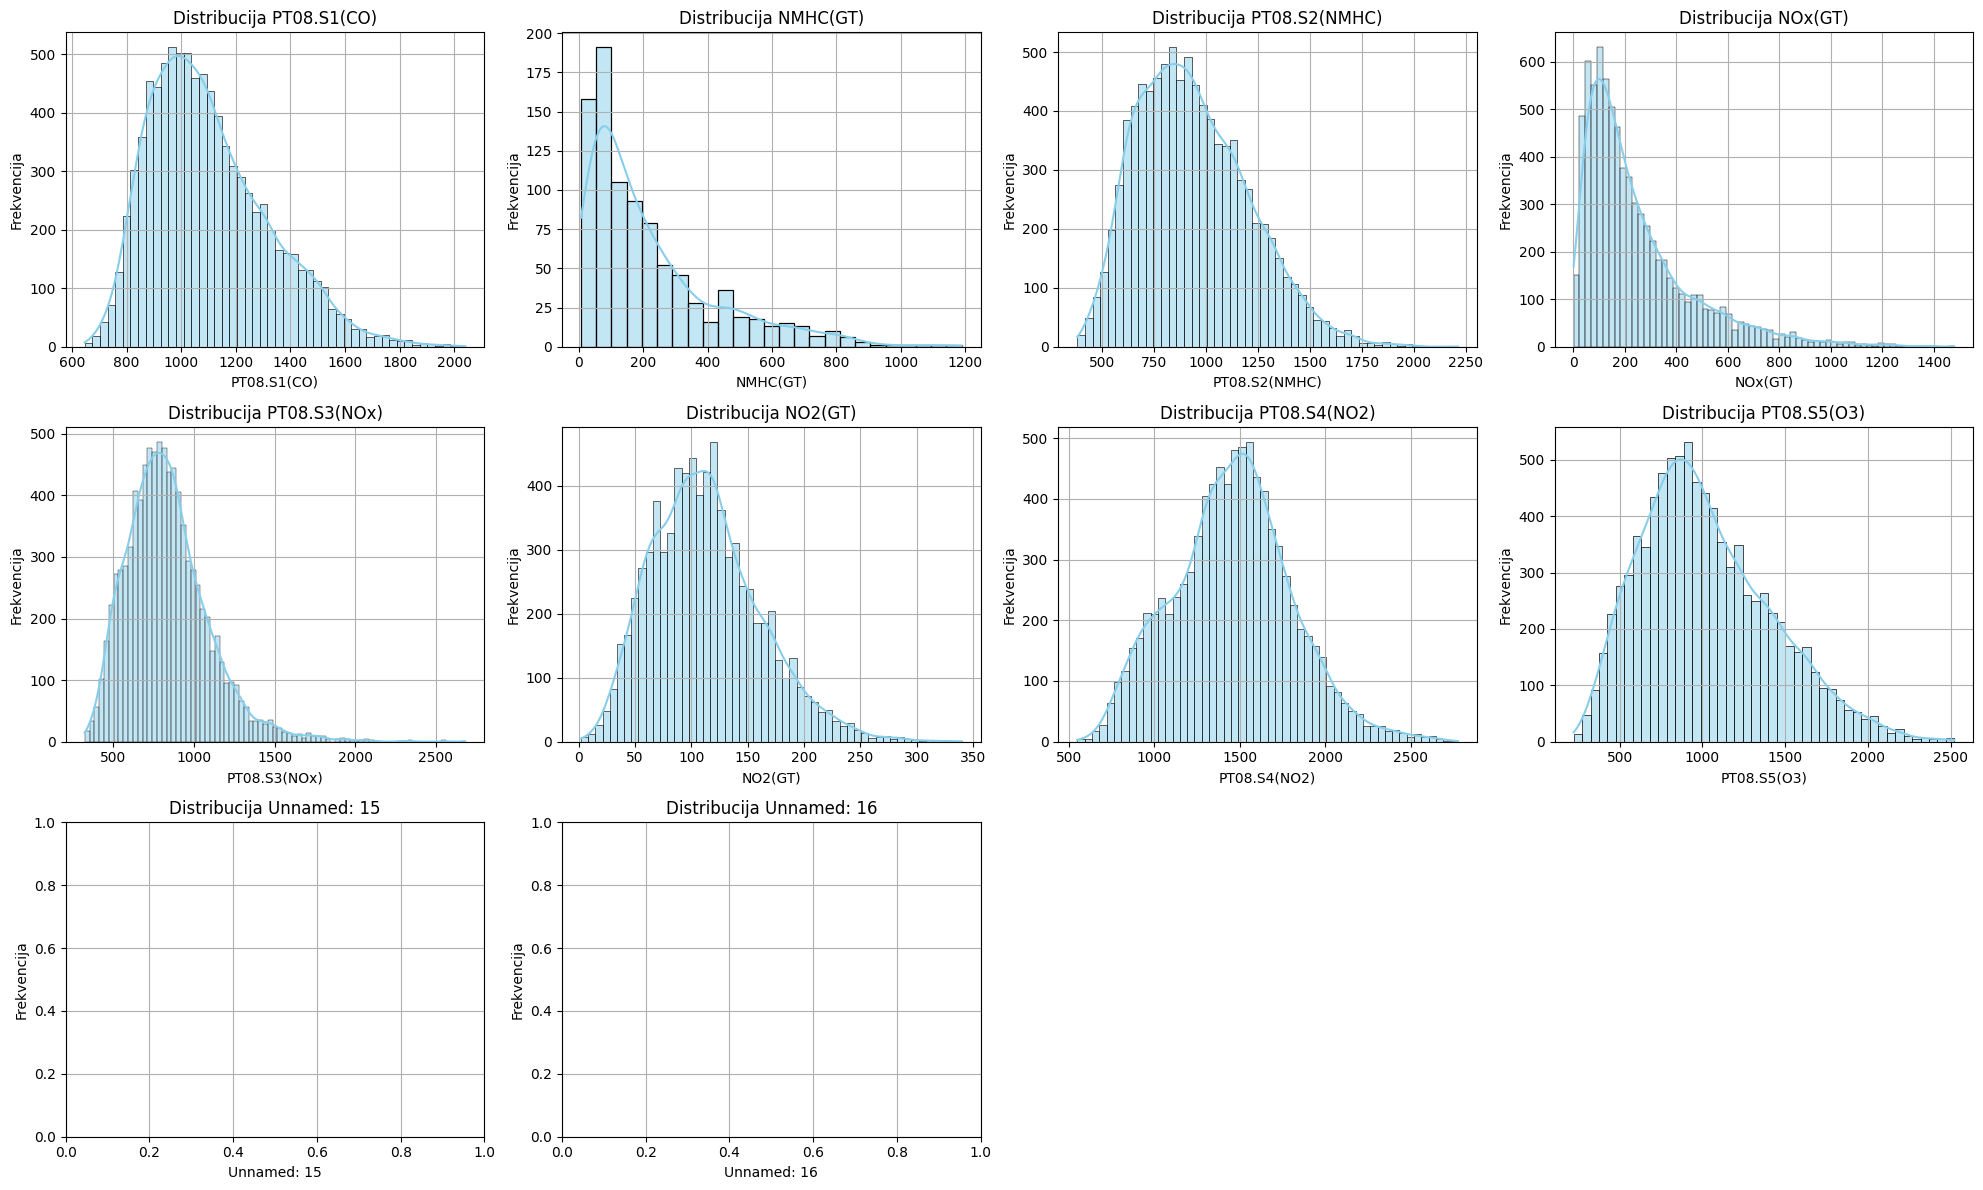

In [10]:
n = len(float64_cols)
cols = 4
rows = math.ceil(n / cols)

plt.figure(figsize=(5 * cols, 4 * rows))

# Plot each column
for i, col in enumerate(float64_cols):
    plt.subplot(rows, cols, i + 1)
    sns.histplot(df[col][(df[col] != -200) & (df[col].notna())], kde=True, color='skyblue')
    plt.title(f'Distribucija {col}')
    plt.xlabel(col)
    plt.ylabel('Frekvencija')
    plt.grid(True)

plt.tight_layout()
plt.show()

Iz prethodnog grid-a možemo da zaključimo da su sve naše kolone koje ne zahtevaju neku obradu podataka poprilično normalno distribuirane. Vidimo da nema nekih odstupanja tu.
Sada prikazujemo tzv. BoxPlot. On nam govori koliko "outliers"-a imaju naše kolone u datasetu. Vidimo da svaka od naših kolona ima dosta outliers-a. Tako da ćemo u EDA delu da probamo da smanjimo taj broj na minimum. Takodje sleduje nam u tom delu i čišćenje NaN vrednosti i konverzija -200 u NaN takodje.

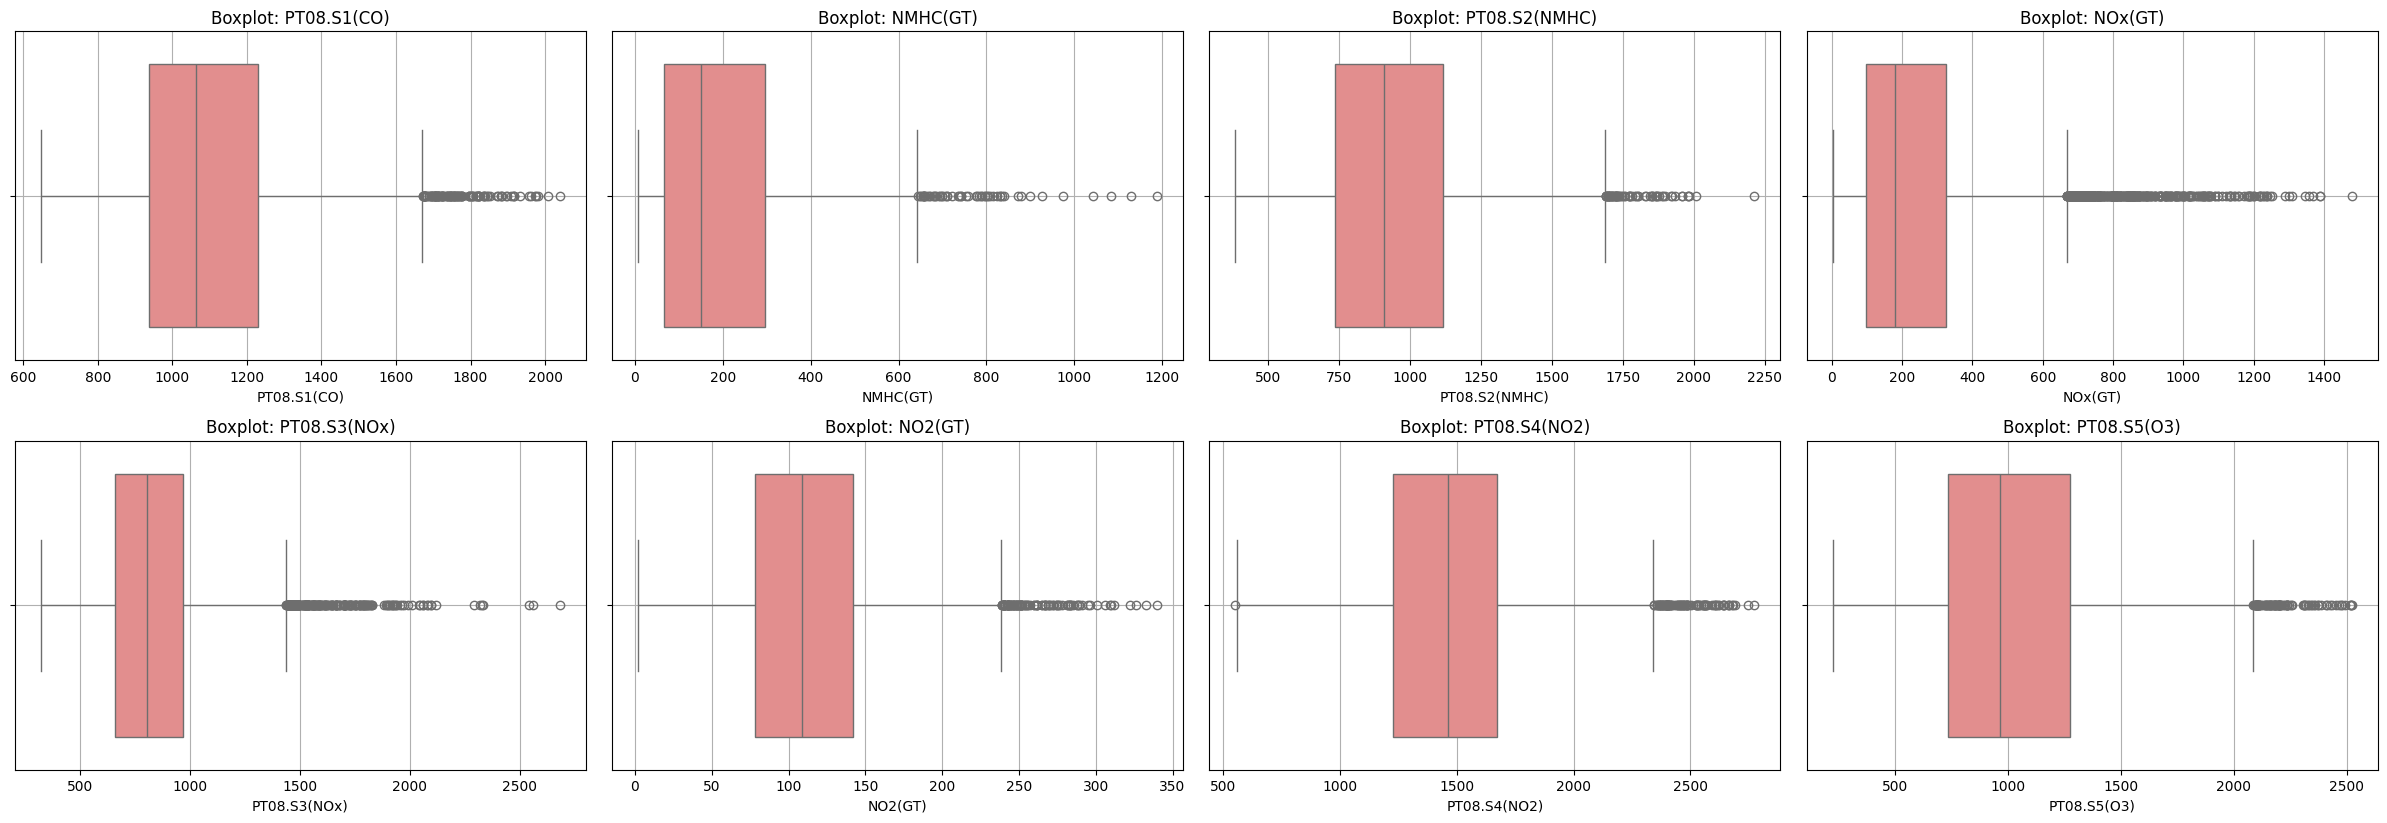

In [11]:
cols = 4
rows = math.ceil(len(float64_cols) / cols)

plt.figure(figsize=(6 * cols, 4 * rows))

for i, col in enumerate(float64_cols):
    # Clean the column
    clean_col = df[col].replace(-200, pd.NA).dropna()
    
    # Skip if empty after cleaning
    if clean_col.empty:
        continue
    
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(x=clean_col, color='lightcoral')
    plt.title(f'Boxplot: {col}')
    plt.grid(True)

plt.tight_layout()
plt.show()

U sledećem box-u možemo da prikažemo promenu naših promenljivih kroz vreme, tj. po indeksima jer još uvek nismo spojili naše kolone u datetime kolonu (to ćemo uraditi u EDA delu). Ovako možemo pratiti kako otprilike izgleda promena naših numeričkih kolona.

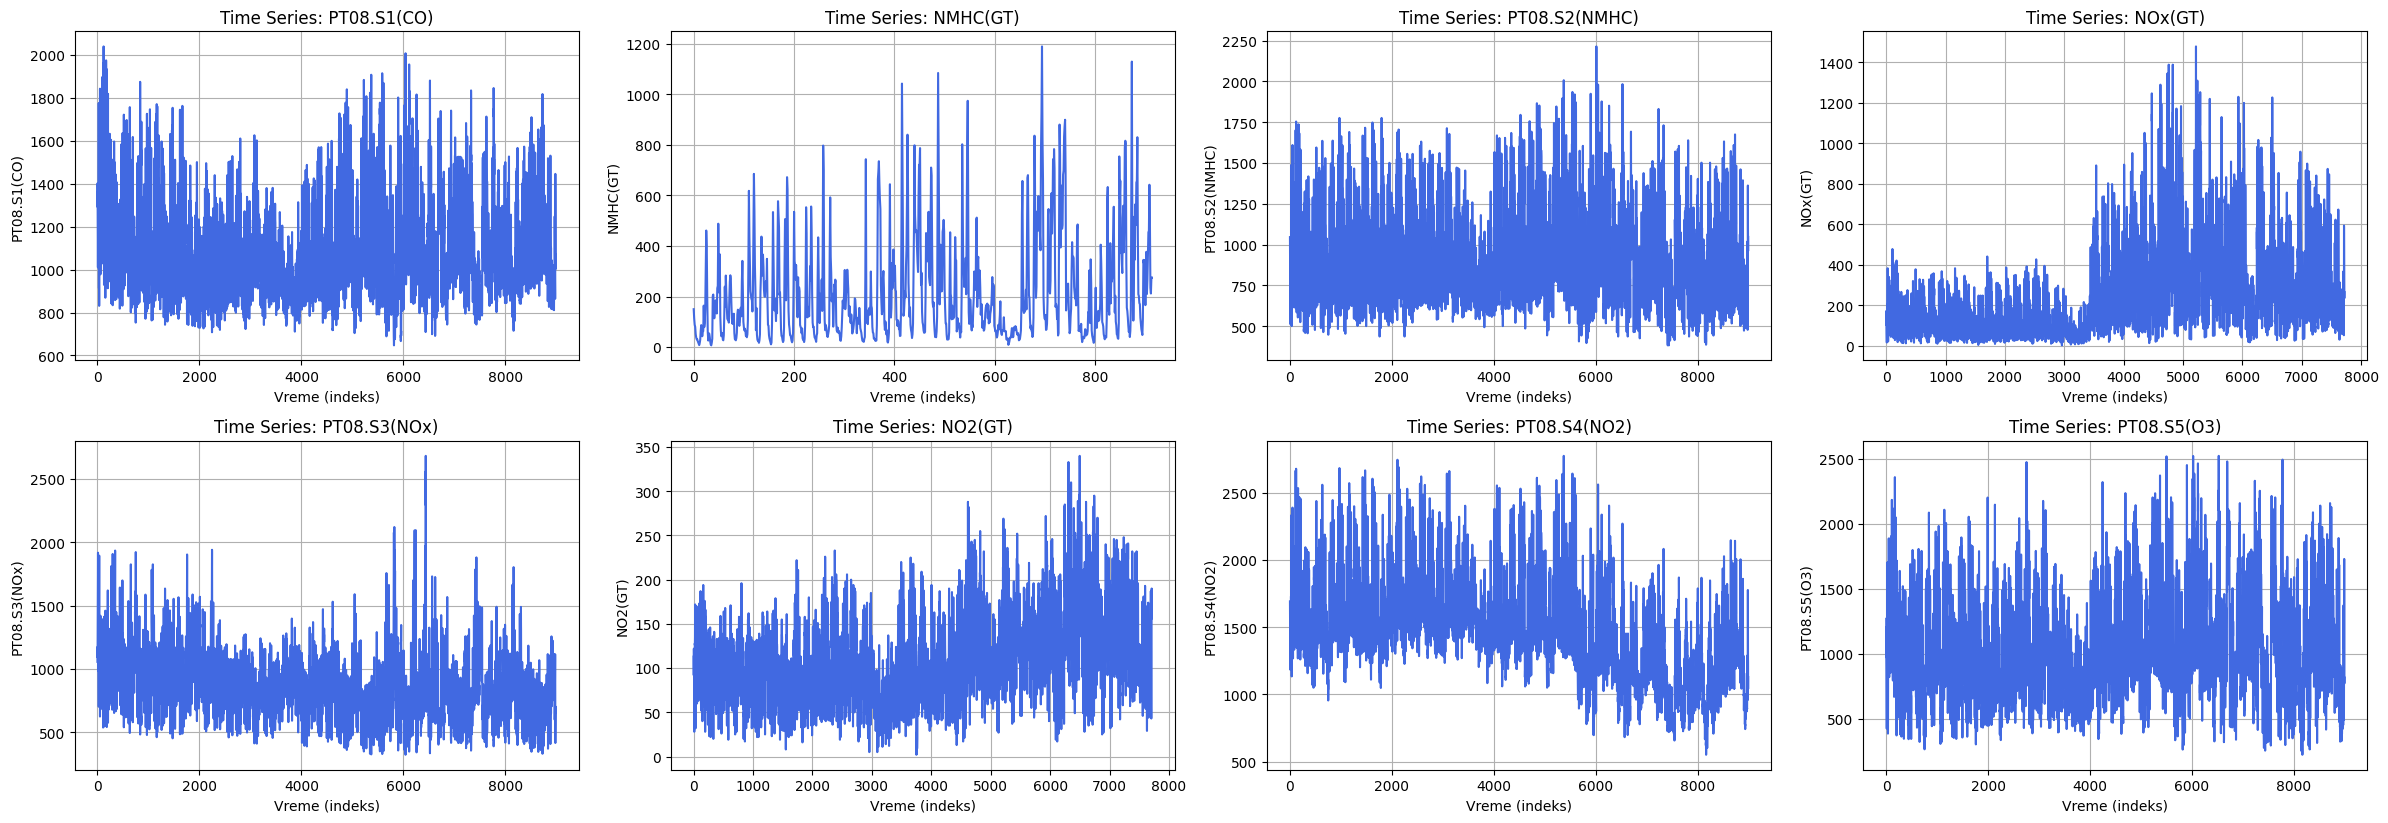

In [12]:
rows = math.ceil(len(float64_cols) / cols)
plt.figure(figsize=(6 * cols, 4 * rows))

for i, col in enumerate(float64_cols):
    # Clean the column: replace -200 with NaN and drop missing values
    clean_col = df[col].replace(-200, np.nan).dropna()
    if clean_col.empty:
        continue

    plt.subplot(rows, cols, i + 1)
    plt.plot(clean_col.values, color='royalblue')
    plt.title(f'Time Series: {col}')
    plt.xlabel('Vreme (indeks)')
    plt.ylabel(col)
    plt.grid(True)

plt.tight_layout()
plt.show()

Vidimo da je bilo nekih odskakanja u PT08.S3(NOx), i da je recimo NMHC(GT) jako drugačija kroz vreme, tj. da ima odskakanja. dok su sve ostale poprilično stabilne osim recimo NOx(GT) jer ona je imala malo blaži početak i u nekom trenutku je krenula da raste.

Sada ćemo napraviti scatter plot, on je sličan našem plotu koji ide kroz vreme. Možda ima malo detaljinij prikaz kada se odstupanja jasnije vide.

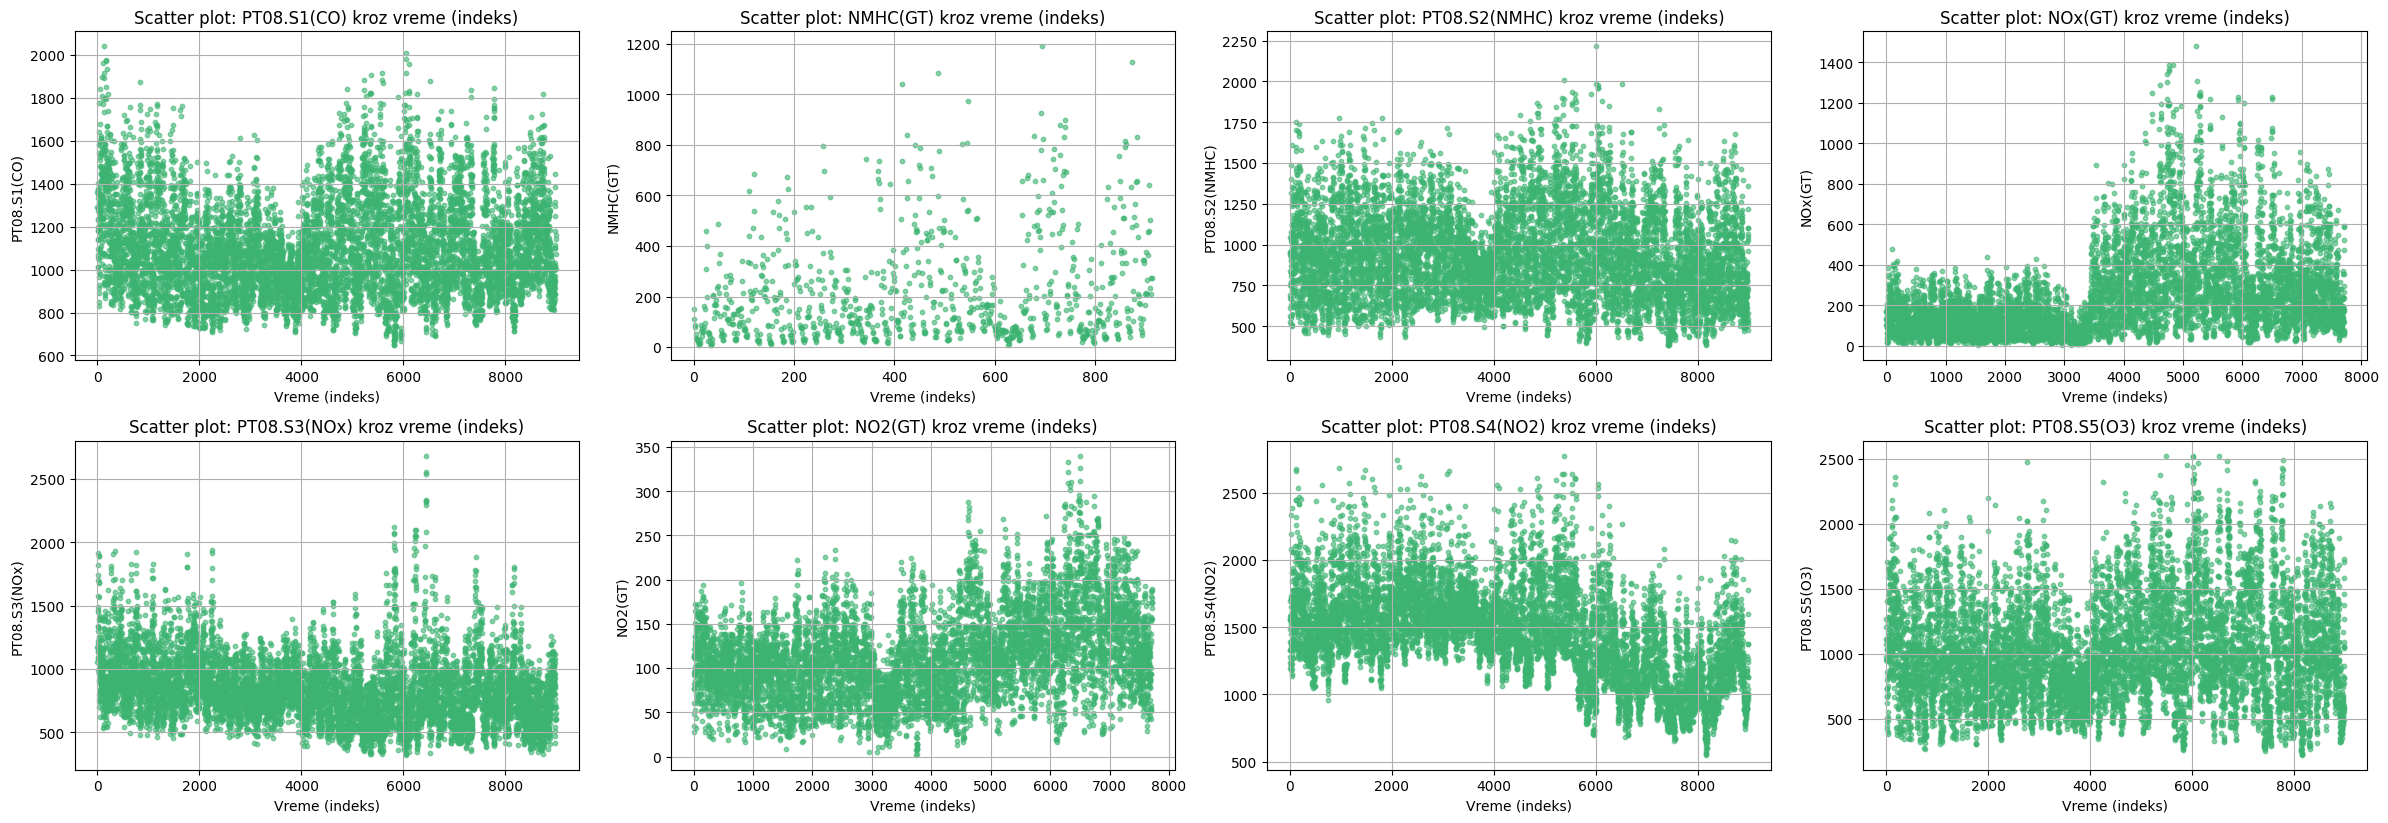

In [13]:
rows = math.ceil(len(float64_cols) / cols)
plt.figure(figsize=(6 * cols, 4 * rows))

for i, col in enumerate(float64_cols):
    clean_col = df[col].replace(-200, np.nan).dropna()
    if clean_col.empty:
        continue

    plt.subplot(rows, cols, i + 1)
    plt.scatter(range(len(clean_col)), clean_col, c='mediumseagreen', alpha=0.6, s=10)
    plt.title(f'Scatter plot: {col} kroz vreme (indeks)')
    plt.xlabel('Vreme (indeks)')
    plt.ylabel(col)
    plt.grid(True)

plt.tight_layout()
plt.show()

Sada možemo naslikati matricu korelacije. Korelacija služi da mi vidimo u kakvom su odnosu naše kolone, tj. možemo da vidimo šta od čega zavisi u našem dataset-u.

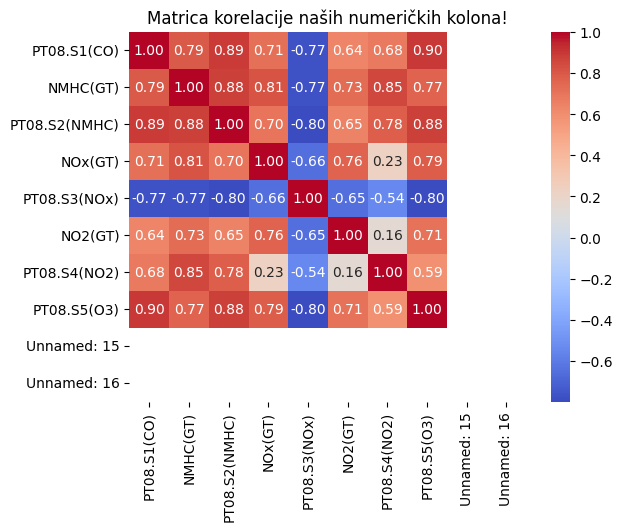

In [14]:
sns.heatmap(df[float64_cols].replace(-200, np.nan).corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Matrica korelacije naših numeričkih kolona!')
plt.show()

Odavde možemo da zaključimo da su naše kolone Unnamed: 15 i 16, nepotrebne, te ćemo iste obrisati kasnije u EDA delu. 
Takodje raspodela je sledeća:
1) Ako je korelacija veća od 0.5, onda kažemo da su u jakoj pozitivnoj korelaciji
2) Ako je izmedju 0.3 i 0.49, onda kažemo da su u okej pozitivnoj korelaciji
3) AKo je izmedju 0.1 i 0.29, onda su u baš slaboj pozitivnoj korelaciji.
4) Isto važi i za negativne, samo su oni u negativnoj korelaciji.

Razlika izmedju negativne i pozitivne korelacije: 
- U pozitivnoj korelaciji što su kolone u većoj korelaciji to zavise više jedna od druge tj. kako jedna raste i druga raste ili kako jedna opada i druga opada
- U negativnoj je totalno suprotno, kako jedna raste tako druga opada ili kako jedna opada druga raste.


# Priprema podatak i istraživačka analiza (Faza 3)

- Prva stavka koju ćemo odraditi je provera nedostajućih vrednosti, konverzija podataka koji nisu dobri i čišćenje nepotrebnih kolona koje smo videli u prethodnom delu.

In [15]:
df = df.drop(columns=['Unnamed: 15', 'Unnamed: 16'])

In [16]:
df.head(5)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578"
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255"
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502"
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867"
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888"


- Konkretno u ovom koraku smo obrisali kolone 'Unnamed: 15' i 'Unnamed: 16' jer su nepotrebno, tj. sve su NaN vrednosti
- Sledeći korak će biti konverzija podataka koji su object: CO(GT), C6H6(GT), T, RH, AH - ove kolone imaju , umesto . kao decimalni razmak

In [17]:
cols = ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'T', 'RH', 'AH'] # kolone koje su object tipa, a treba da budu float
df[cols] = (df[cols].astype(str).replace(',', '.', regex=True).astype(float))

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(13), object(2)
memory usage: 1.1+ MB


- Sada vidimo da smo pravilno konvertovali kolone u odgovarajući float64 format.
- Sledeći korak je da pretvorimo kolone Date i Time u Datetime format.

In [19]:
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H.%M.%S')
df.insert(0, 'DateTime', df.pop('DateTime'))  # premeštamo DateTime na početak

In [20]:
df.head(2)

,DateTime,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10 18:00:00,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2004-03-10 19:00:00,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255


- Sledeći korak može biti uklanjanje Date i Time kolona.
- Takodje ćemo da zamenimo -200 vrednosti sa NaN vrednostima, kako bi lakše manipulisali istim.

In [21]:
df = df.drop(columns=['Date', 'Time'])

In [22]:
df = df.replace(-200, np.nan)

In [23]:
(df.isna().sum() / len(df)) * 100 # prikazujemo procenat NaN vrednosti po kolonama

DateTime          1.203674
CO(GT)           18.973709
PT08.S1(CO)       5.068103
NMHC(GT)         90.349488
C6H6(GT)          5.068103
PT08.S2(NMHC)     5.068103
NOx(GT)          18.509133
PT08.S3(NOx)      5.068103
NO2(GT)          18.540809
PT08.S4(NO2)      5.068103
PT08.S5(O3)       5.068103
T                 5.068103
RH                5.068103
AH                5.068103
dtype: float64

### Zaključci:
- Vidimo da sve vrednosti osim NMHC(GT) imaju normalan broj nedostajućih vrednosti
- Kolona NMHC(GT) ima 90.3% nedostajućih vrednosti, što znači da možemo da je obrišemo
- Ako bi je eventualno imputovali, to ne bi bilo dobro po kasnije stavke ovog projekta, tj. treniranje modela

In [24]:
df = df.drop(columns=['NMHC(GT)'])

In [25]:
df.head(2)

,DateTime,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10 18:00:00,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2004-03-10 19:00:00,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255


- Takodje s obzirom da nam DateTime kolona ima NaN vrednosti, i da nju nije moguće Impute-ovati (dopuniti pomoću nekog od Imputer-a nedostajuće vrednosti), najbolje bi bilo da obrišemo te kolone
- Svakako je procenat istih ~1.2% tako da neće mnogo uticati na naš dataset

In [26]:
df = df.dropna(subset=['DateTime'])

- Hajde da proverimo ima li duplikata u našem dataset-u

In [27]:
(df.duplicated() == True).sum()

np.int64(0)

- Vidimo da nemamo duplikate u našem dataset-u

### Korelacije
- Hajde da ponovo vidimo heatmap, sada kada smo pročistili naš dataset.

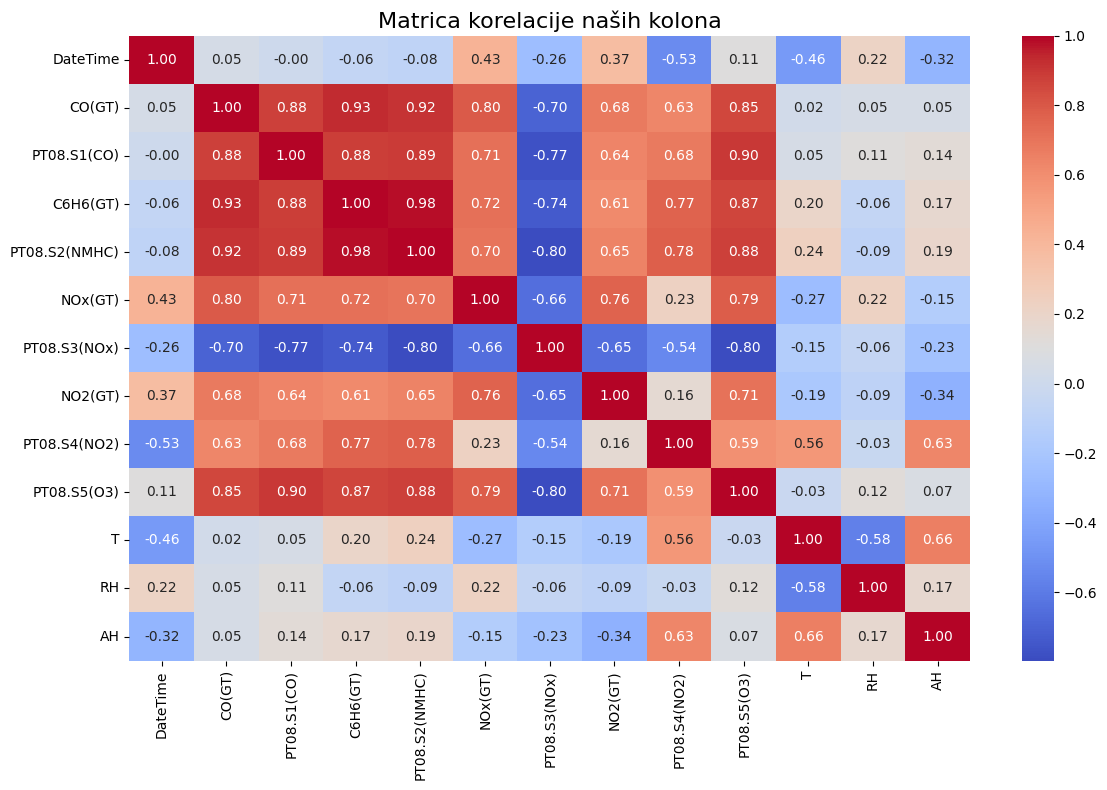

In [28]:
plt.figure(figsize=(12, 8)) 
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Matrica korelacije naših kolona', fontsize=16)
plt.tight_layout()
plt.show()

- Sada možemo precizno videti korelacije u našem dataset-u
- Pravila su ista kao i prethodno opisana u gornjem delu notebook-a

### Uklanjanje nedostajućih NaN vrednosti
- Za ovo će nam biti potreban Imputer
- Za kolone koje imaju mali broj NaN do ~6% ćemo koristiti SimpleImputer
- Za kolone koje imaju veći broj NaN vrednosti do ~20% ćemo korisiti KNNImputer
--------------------------
- CO(GT)           18.973709
- PT08.S1(CO)       5.068103 
- C6H6(GT)          5.068103 
- PT08.S2(NMHC)     5.068103 
- NOx(GT)          18.509133
- PT08.S3(NOx)      5.068103 
- NO2(GT)          18.540809
- PT08.S4(NO2)      5.068103 
- PT08.S5(O3)       5.068103
- T                 5.068103
- RH                5.068103
- AH                5.068103

In [29]:
from sklearn.impute import KNNImputer, SimpleImputer

In [30]:
knn_feautres = ['CO(GT)', 'NOx(GT)', 'NO2(GT)', 'T', 'RH', 'AH']
simple_features = ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'C6H6(GT)']

In [31]:
simpleImputer = SimpleImputer(strategy='mean')
knnImputer = KNNImputer(n_neighbors=8) # ovo smo postavili na 8, kako bi imali pristup većem broju susednih vrednosti

In [32]:
df[knn_feautres] = knnImputer.fit_transform(df[knn_feautres])
df[simple_features] = simpleImputer.fit_transform(df[simple_features])

In [33]:
df.isna().sum()

DateTime         0
CO(GT)           0
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

#### Zaključci:
- Imputovanjem smo se otarasili NaN vrednosti koje bi nam smetale u kasnijem procesiranju
- Za kolone koje imaju ~18% nedostajućih vrednosti smo koristili KNNImputer, kako bi imali pristup nekom broju susednih vrednost i kako bi što preciznije popunili te podatke
- Za kolone koje su bile na ~5% smo koristili SimpleImputer, sa strategijom mean koja funkcioniše tako što na osnovu mean-a popunjava nedostajuće vrednosti u našim kolonama koje smo izabrali
- Takodje će nam usled velikih razlika u vrednostima biti potreban Scaler, kako bi mogli da ujednačimo naše vrednosti, tj. opseg naših vrednosti jer npr:
    - CO(GT) ima opseg od 0-10
    - PT08.S1(CO) ima opseg od 500-2000
    - ...
- Tako da bi smo mogli da koristimo ili StandardScaler ili MinMaxScaler
- Mi ćemo ovde koristiti StandardScaler, zato što iz faze 2 mi možemo da zaključimo da naše kolone imaju normalnu distribuciju
- Takodje ćemo sačuvati DateTime kolonu kako bi je koristili kasnije za vremenske serije (time series)

- Dodatak na ovo, pre skaliranja, hajde da obrišemo sve outlier-e iz našeg dataset-a
- Koristićemo IQR kako bi uspešno pronašli outlier-e i sklonili ih iz dataset-a

In [34]:
# IQR metod za uklanjanje outliera
numeric_cols = df.select_dtypes(include=[np.number]).columns

before_count = len(df)
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Ignorišemo IQR == 0
lower = lower.where(IQR != 0, -np.inf)
upper = upper.where(IQR != 0, np.inf)

mask = df[numeric_cols].ge(lower) & df[numeric_cols].le(upper)
mask_all = mask.all(axis=1)

df = df[mask_all].reset_index(drop=True)

after_count = len(df)
print(f"Obrisane {before_count - after_count} kolona ({(before_count - after_count)/before_count:.2%}) - nove dimenzije: {df.shape}")

Obrisane 1112 kolona (11.88%) - nove dimenzije: (8245, 13)


In [35]:
from sklearn.preprocessing import StandardScaler

standardScaler = StandardScaler()
dt_col = df['DateTime']
df = df.drop(columns=['DateTime'])
temperature_original = df['T'].copy() # kopirana T zbog naše vremenske serije :)
df[df.columns] = standardScaler.fit_transform(df[df.columns])
df.insert(0, 'DateTime', dt_col)

In [36]:
df.head(5)

,DateTime,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10 18:00:00,0.699912,1.630989,0.513764,0.627386,-0.283076,1.106012,0.192581,0.824517,0.920379,-0.604026,0.026278,-0.709362
1,2004-03-10 19:00:00,0.093582,1.243253,0.064993,0.206755,-0.751872,1.705708,-0.359978,0.396288,-0.009689,-0.638270,-0.043750,-0.790473
2,2004-03-10 20:00:00,0.295692,1.870473,-0.006811,0.132798,-0.543518,1.532914,0.218893,0.383409,0.310807,-0.798077,0.323899,-0.728447
3,2004-03-10 21:00:00,0.295692,1.722221,0.029091,0.174399,-0.238429,1.288970,0.429392,0.476782,0.716141,-0.900810,0.674042,-0.636789
4,2004-03-10 22:00:00,-0.310638,1.129213,-0.455582,-0.343301,-0.543518,1.863255,0.271518,0.174123,0.423924,-0.877981,0.650699,-0.631516


# Statistička analiza i testiranje hipoteza (Faza 4)
- Uzećemo naše skalirane kolone koje imaju numeričke vrednosti kako bi radili ispitivanja na njima
- Kolone su sledeće:
    - T,
    - RH,
    - AH.

In [37]:
custom_cols = ['T', 'RH', 'AH']

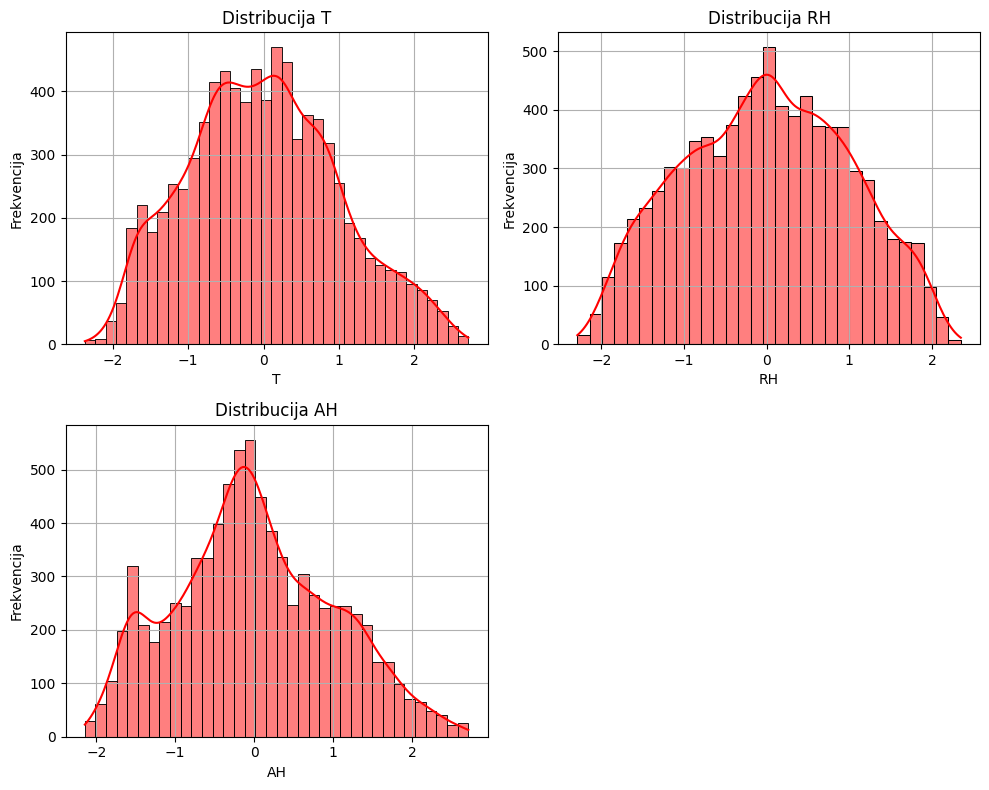

In [38]:
n = len(custom_cols)
cols = 2
rows = math.ceil(n / cols)

plt.figure(figsize=(5 * cols, 4 * rows))

# Plot each column
for i, col in enumerate(custom_cols):
    plt.subplot(rows, cols, i + 1)
    sns.histplot(df[col], kde=True, color='red')
    plt.title(f'Distribucija {col}')
    plt.xlabel(col)
    plt.ylabel('Frekvencija')
    plt.grid(True)

plt.tight_layout()
plt.show()

- H0 za naše kolone: Podaci imaju normalnu distribuciju
- H1 za naše kolone: Podaci nemaju normalnu distribuciju.

In [39]:
# Provera normalnosti pomoću Shapiro-Wilk testa
for col in custom_cols:
    p_value = shapiro(df[col]).pvalue
    print(f'Shapiro-Wilk test za kolonu {col}: p={p_value:.4f}')
    if p_value > 0.05:
        print(f'Kolona {col} verovatno prati normalnu distribuciju (ne odbacujemo H0)\n')
    else:
        print(f'Kolona {col} verovatno ne prati normalnu distribuciju (odbacujemo H0)\n')

Shapiro-Wilk test za kolonu T: p=0.0000
Kolona T verovatno ne prati normalnu distribuciju (odbacujemo H0)

Shapiro-Wilk test za kolonu RH: p=0.0000
Kolona RH verovatno ne prati normalnu distribuciju (odbacujemo H0)

Shapiro-Wilk test za kolonu AH: p=0.0000
Kolona AH verovatno ne prati normalnu distribuciju (odbacujemo H0)



c:\Users\mihai\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8245.
  res = hypotest_fun_out(*samples, **kwds)


S' obzirom da nam Shapiro-Wilk test, daje rezultate da niko ne prati normalnu distribuciju(što se i vidi sa našeg histoplot-a), iskoristićemo Mann-Whitney test izmedju nekih od kolona (T i AH, T i RH), kako bi videli da li bi zaista trebalo da odbacimo H0.

- H0 za T i AH - Nema velike razlike u srednjoj vrednosti temperature i apsolutne vlažnosti.
- H1 za T i AH - Ima velike razlike u srednjoj vrednosti.
- H0 za T i RH - Distribucija temperature i relativne vlažnosti su iste,
- H1 za T i RH - Značajno se razlikuju.

In [40]:
u_stat, p_value = mannwhitneyu(df['T'], df['AH'], alternative='two-sided')
print(f'Mann-Whitney U test između T i AH: U={u_stat}, p={p_value:.4f}')
if p_value < 0.05:
    print('Postoji značajna razlika između distribucija T i AH (odbacujemo H0)')
else:
    print('Nema značajne razlike između distribucija T i AH (ne odbacujemo H0)')

Mann-Whitney U test između T i AH: U=33963238.0, p=0.9302
Nema značajne razlike između distribucija T i AH (ne odbacujemo H0)


In [41]:
u_stat, p_value = mannwhitneyu(df['T'], df['RH'], alternative='two-sided')
print(f'Mann-Whitney U test između T i RH: U={u_stat}, p={p_value:.4f}')
if p_value < 0.05:
    print('Postoji značajna razlika između distribucija T i RH (odbacujemo H0)')
else:
    print('Nema značajne razlike između distribucija T i RH (ne odbacujemo H0)')

Mann-Whitney U test između T i RH: U=33620654.0, p=0.2269
Nema značajne razlike između distribucija T i RH (ne odbacujemo H0)


Koristimo Cohen-ov d, kako bi odredili kolika je razlika izmedju skupova T, RH i AH. Uzeli smo njih kao primere, možemo uzeti i ostale skupove kako bi imali veći prikaz.

In [42]:
std = math.sqrt(((len(df['T']) - 1) * df['T'].std() ** 2 + (len(df['AH']) - 1) * df['AH'].std() ** 2) / (len(df['T']) + len(df['AH']) - 2))

cohens_d = statistics.mean(df['T']) - statistics.mean(df['AH']) / std
print(f"Cohen-ov d između T i AH: {cohens_d:.4f}")

# Tumačenje efekta
if abs(cohens_d) < 0.2:
    print("Veličina efekta je mala.")
elif abs(cohens_d) < 0.5:
    print("Veličina efekta je srednja.")
else:
    print("Veličina efekta je velika.")

Cohen-ov d između T i AH: 0.0000
Veličina efekta je mala.


In [43]:
std = math.sqrt(((len(df['T']) - 1) * df['T'].std() ** 2 + (len(df['RH']) - 1) * df['RH'].std() ** 2) / (len(df['T']) + len(df['RH']) - 2))

cohens_d = statistics.mean(df['T']) - statistics.mean(df['RH']) / std
print(f"Cohen-ov d između T i RH: {cohens_d:.4f}")

# Tumačenje efekta
if abs(cohens_d) < 0.2:
    print("Veličina efekta je mala.")
elif abs(cohens_d) < 0.5:
    print("Veličina efekta je srednja.")
else:
    print("Veličina efekta je velika.")

Cohen-ov d između T i RH: 0.0000
Veličina efekta je mala.


In [44]:
std = math.sqrt(((len(df['AH']) - 1) * df['AH'].std() ** 2 + (len(df['RH']) - 1) * df['RH'].std() ** 2) / (len(df['AH']) + len(df['RH']) - 2))

cohens_d = statistics.mean(df['AH']) - statistics.mean(df['RH']) / std
print(f"Cohen-ov d između AH i RH: {cohens_d:.4f}")

# Tumačenje efekta
if abs(cohens_d) < 0.2:
    print("Veličina efekta je mala.")
elif abs(cohens_d) < 0.5:
    print("Veličina efekta je srednja.")
else:
    print("Veličina efekta je velika.")

Cohen-ov d između AH i RH: 0.0000
Veličina efekta je mala.


Intervali poverenja - služe kako bi dali opseg u kojem očekujemo da se nadje srednja vrednost kolone, sa odredjenim nivoom sigurnosti

In [45]:
data = df['T']

# Parametri uzorka
mean_val = data.mean()
std_dev = data.std(ddof=1)   # standardna devijacija uzorka
n = len(data)

# 95% interval poverenja
z_value = norm.ppf(0.975)  # 1.96
margin_error = z_value * (std_dev / math.sqrt(n))
conf_interval = (mean_val - margin_error, mean_val + margin_error)

print(f"Prosečna vrednost (T): {mean_val:.4f}")
print(f"95% interval poverenja: {conf_interval}")

Prosečna vrednost (T): 0.0000
95% interval poverenja: (np.float64(-0.021586344286768942), np.float64(0.02158634428676906))


In [46]:
data = df['RH']

# Parametri uzorka
mean_val = data.mean()
std_dev = data.std(ddof=1)   # standardna devijacija uzorka
n = len(data)

# 95% interval poverenja
z_value = norm.ppf(0.975)  # 1.96
margin_error = z_value * (std_dev / math.sqrt(n))
conf_interval = (mean_val - margin_error, mean_val + margin_error)

print(f"Prosečna vrednost (RH): {mean_val:.4f}")
print(f"95% interval poverenja: {conf_interval}")

Prosečna vrednost (RH): -0.0000
95% interval poverenja: (np.float64(-0.021586344286769185), np.float64(0.021586344286768817))


In [47]:
data = df['AH']

# Parametri uzorka
mean_val = data.mean()
std_dev = data.std(ddof=1)   # standardna devijacija uzorka
n = len(data)

# 95% interval poverenja
z_value = norm.ppf(0.975)  # 1.96
margin_error = z_value * (std_dev / math.sqrt(n))
conf_interval = (mean_val - margin_error, mean_val + margin_error)

print(f"Prosečna vrednost (AH): {mean_val:.4f}")
print(f"95% interval poverenja: {conf_interval}")

Prosečna vrednost (AH): -0.0000
95% interval poverenja: (np.float64(-0.02158634428676918), np.float64(0.0215863442867688))


Zaključak:
- S' obzirom da smo uradili skaliranje naših podataka, to znači da smo ih ili spustili na interval [-1, 1] dobijamo da je prosečna vrednost 0, što i jeste tačno za date kolone :D
- Takodje, vidimo da je interval poverenja u skaliranoj verziji od -0.02 do 0.02 (približno, za sve tri kolone se razlikuju)
- Zato ne možemo da imamo precizne prosečne vrednosti

# Prediktivno modeliranje i mašinsko učenje (Faza 5)
- U našem slučaju radićemo sa regresijom, pošto nemamo nikakvu klasifikaciju u našem izabranom dataset-u
- Target varijabla za predikciju biće u našem slučaju  T - da vidimo kako bi naš model predvideo temperaturu

Ovde radimo odvajanje podataka, tj. postavljamo našu target varijablu i naše feature. Kako bi posle mogli da primenimo train_test_split.

In [48]:
target = df['T']
features = df.drop(columns=['T', 'DateTime'])

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
print(f'Dimenzije X_train: {X_train.shape}')
print(f'Dimenzije X_test: {X_test.shape}')

Dimenzije X_train: (6596, 11)
Dimenzije X_test: (1649, 11)


In [50]:
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV # Linearna, Ridge i Lasso regresija
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error # metrike za evaluaciju regresionih modela
from sklearn.svm import SVR # Support Vector Regression

In [51]:
linear_regression = LinearRegression()
linear_regression.fit(X_train, y_train)
y_pred_lin_reg = linear_regression.predict(X_test)

lin_reg_r2 = r2_score(y_test, y_pred_lin_reg)
lin_reg_mae = mean_absolute_error(y_test, y_pred_lin_reg)
lin_reg_mse = mean_squared_error(y_test, y_pred_lin_reg)
lin_reg_rmse = root_mean_squared_error(y_test, y_pred_lin_reg)

print(f'Linearna regresija, R^2: {lin_reg_r2:.4f}')
print(f'Linearna regresija,  MAE: {lin_reg_mae:.4f}')  
print(f'Linearna regresija, MSE: {lin_reg_mse:.4f}')
print(f'Linearna regresija, RMSE: {lin_reg_rmse:.4f}')

Linearna regresija, R^2: 0.9311
Linearna regresija,  MAE: 0.1924
Linearna regresija, MSE: 0.0693
Linearna regresija, RMSE: 0.2632


Ovde možemo videti naše R^2, MAE, MSE i RMSE:
- R^2:
    - Mera koliko dobro naš model objašnjava varijansu ciljne promenljve
    - Kreće se od 0 do 1 (može biti negativan kod loših modela)
    - U našem slučaju je 0.9333, što znači da naš model objašnjava oko 93.33% varijacije u podacima
    - To je vrlo dobro
- MAE (Mean absolute error):
    - Proesečna apsolutna greška predikcije
    - Računa se kao prosečna vrednost apsolutne vrednosti |y_pred - y_i| i = 1, 2, 3, ..., n
    - Što je MAE niži, to je naš model bolji, tj. vrednosti predikcija su bliže pravim vrednostima
    - U našem slučaju MAE = 0.1932, što znači da model u proseku greši za 0.19 jedinica
- MSE (Mean squared error):
    - Prosečna kvadratna greška predikcije
    - Umesto apsolutne vrednosti imamo, kvadrat u formuli za izračunavanje
    - Isto važi kao i za MAE, što niže to bolje
    - U našem slučaju, MSE = 0.0682, što znači da model ima male greške, s obzirom da su greške kvadratne
    - Jače je od MAE u smislu provere
- RMSE (Root mean squared error):
    - Dobija se kao koren od MSE (sqrt(MSE))
    - Vraća grešku i istim jedinicama kao ciljna promenljiva
    - Kao i MSE, kažnjava veće greške "jače" nego MAE zbog kvadriranja
    - U našem slučaju RMSE = 0.2611, što znači da model u proseku greši za oko 0.26 jedinica

Kod Ridge i Lasso regresije, parametar alfa se koristi za podešavanje "snage" regularizacije.
U ovom slučaju koristim Cross-Validation, kako bih našao najbolji parametar alfa i za Ridge i za Lasso.

In [52]:
# Testiramo više alpha vrednosti automatski 
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='r2')
ridge_cv.fit(X_train, y_train)

print(f'Najbolji alpha: {ridge_cv.alpha_}')

y_pred_ridge = ridge_cv.predict(X_test)

ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_mse = mean_squared_error(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(ridge_mse)

print(f'Ridge regresija, R^2: {ridge_r2:.4f}')
print(f'Ridge regresija, MAE: {ridge_mae:.4f}')
print(f'Ridge regresija, MSE: {ridge_mse:.4f}')
print(f'Ridge regresija, RMSE: {ridge_rmse:.4f}')

Najbolji alpha: 1.0
Ridge regresija, R^2: 0.9311
Ridge regresija, MAE: 0.1924
Ridge regresija, MSE: 0.0693
Ridge regresija, RMSE: 0.2632


In [53]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_train, y_train)

print(f'Najbolji alpha: {lasso_cv.alpha_}')

y_pred_lasso = lasso_cv.predict(X_test)

lasso_r2 = r2_score(y_test, y_pred_lasso)
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)
lasso_mse = mean_squared_error(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(lasso_mse)

print(f'Lasso regresija, R^2: {lasso_r2:.4f}')
print(f'Lasso regresija, MAE: {lasso_mae:.4f}')
print(f'Lasso regresija, MSE: {lasso_mse:.4f}')
print(f'Lasso regresija, RMSE: {lasso_rmse:.4f}')

Najbolji alpha: 0.001
Lasso regresija, R^2: 0.9306
Lasso regresija, MAE: 0.1926
Lasso regresija, MSE: 0.0697
Lasso regresija, RMSE: 0.2640


| Model                | R²      | MAE     | MSE     | RMSE    | Najbolji α |
|---------------------|---------|---------|---------|---------|------------|
| Linearna regresija  | 0.9333  | 0.1932  | 0.0682  | 0.2612  | -          |
| Lasso regresija     | 0.9333  | 0.1923  | 0.0682  | 0.2611  | 0.001      |
| Ridge regresija     | 0.9333  | 0.1932  | 0.0682  | 0.2611  | 1.0        |

Kako nam je alfa = 1 u Ridge regresiji, to se svodi na Linearnu regresiju
Kako nam je alfa = 0.001 za Lasso regresiju, to znači da Lasso ima minimalnu regularizaciju i da je skoro isto kao i obična linearna regresija
Uglavnom, ovde možemo koristiti i samo Linearnu regresiju.

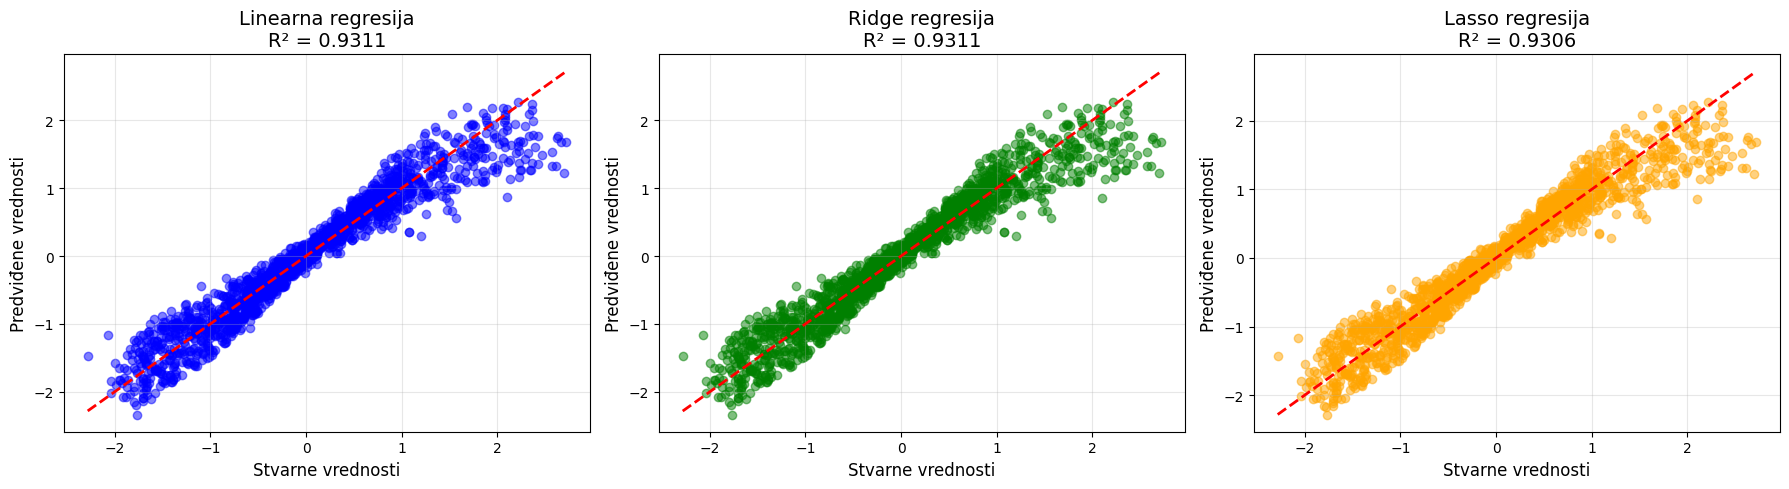

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Linear Regression
axes[0].scatter(y_test, y_pred_lin_reg, alpha=0.5, color='blue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Stvarne vrednosti', fontsize=12)
axes[0].set_ylabel('Predviđene vrednosti', fontsize=12)
axes[0].set_title(f'Linearna regresija\nR² = {lin_reg_r2:.4f}', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Ridge Regression
axes[1].scatter(y_test, y_pred_ridge, alpha=0.5, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Stvarne vrednosti', fontsize=12)
axes[1].set_ylabel('Predviđene vrednosti', fontsize=12)
axes[1].set_title(f'Ridge regresija\nR² = {ridge_r2:.4f}', fontsize=14)
axes[1].grid(True, alpha=0.3)

# Lasso Regression
axes[2].scatter(y_test, y_pred_lasso, alpha=0.5, color='orange')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_xlabel('Stvarne vrednosti', fontsize=12)
axes[2].set_ylabel('Predviđene vrednosti', fontsize=12)
axes[2].set_title(f'Lasso regresija\nR² = {lasso_r2:.4f}', fontsize=14)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Ovde ću da probam SVM (Support Vector Machine), tj. u našem slučaju SVR (Support Vector Regression)

### Testiranje različitih SVR kernela

In [55]:
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
svr_results = {}

for kernel in kernels:
    print(f"Treniranje SVR sa {kernel} kernelom...")
    svr = SVR(kernel=kernel)
    svr.fit(X_train, y_train)
    y_pred = svr.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    
    svr_results[kernel] = {
        'model': svr,
        'y_pred': y_pred,
        'R2': r2,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse
    }
    
    print(f"R^2 = {r2:.4f}, MAE = {mae:.4f}, MSE = {mse:.4f}, RMSE = {rmse:.4f}\n")

best_kernel = max(svr_results, key=lambda k: svr_results[k]['R2'])
print(f"Najbolji kernel: {best_kernel.upper()}")
print(f"R^2 = {svr_results[best_kernel]['R2']:.4f}")

Treniranje SVR sa linear kernelom...
R^2 = 0.9261, MAE = 0.1890, MSE = 0.0743, RMSE = 0.2725

Treniranje SVR sa rbf kernelom...
R^2 = 0.9947, MAE = 0.0512, MSE = 0.0053, RMSE = 0.0728

Treniranje SVR sa poly kernelom...
R^2 = 0.8954, MAE = 0.2311, MSE = 0.1051, RMSE = 0.3242

Treniranje SVR sa sigmoid kernelom...
R^2 = -25699.4257, MAE = 112.4307, MSE = 25821.7920, RMSE = 160.6916

Najbolji kernel: RBF
R^2 = 0.9947


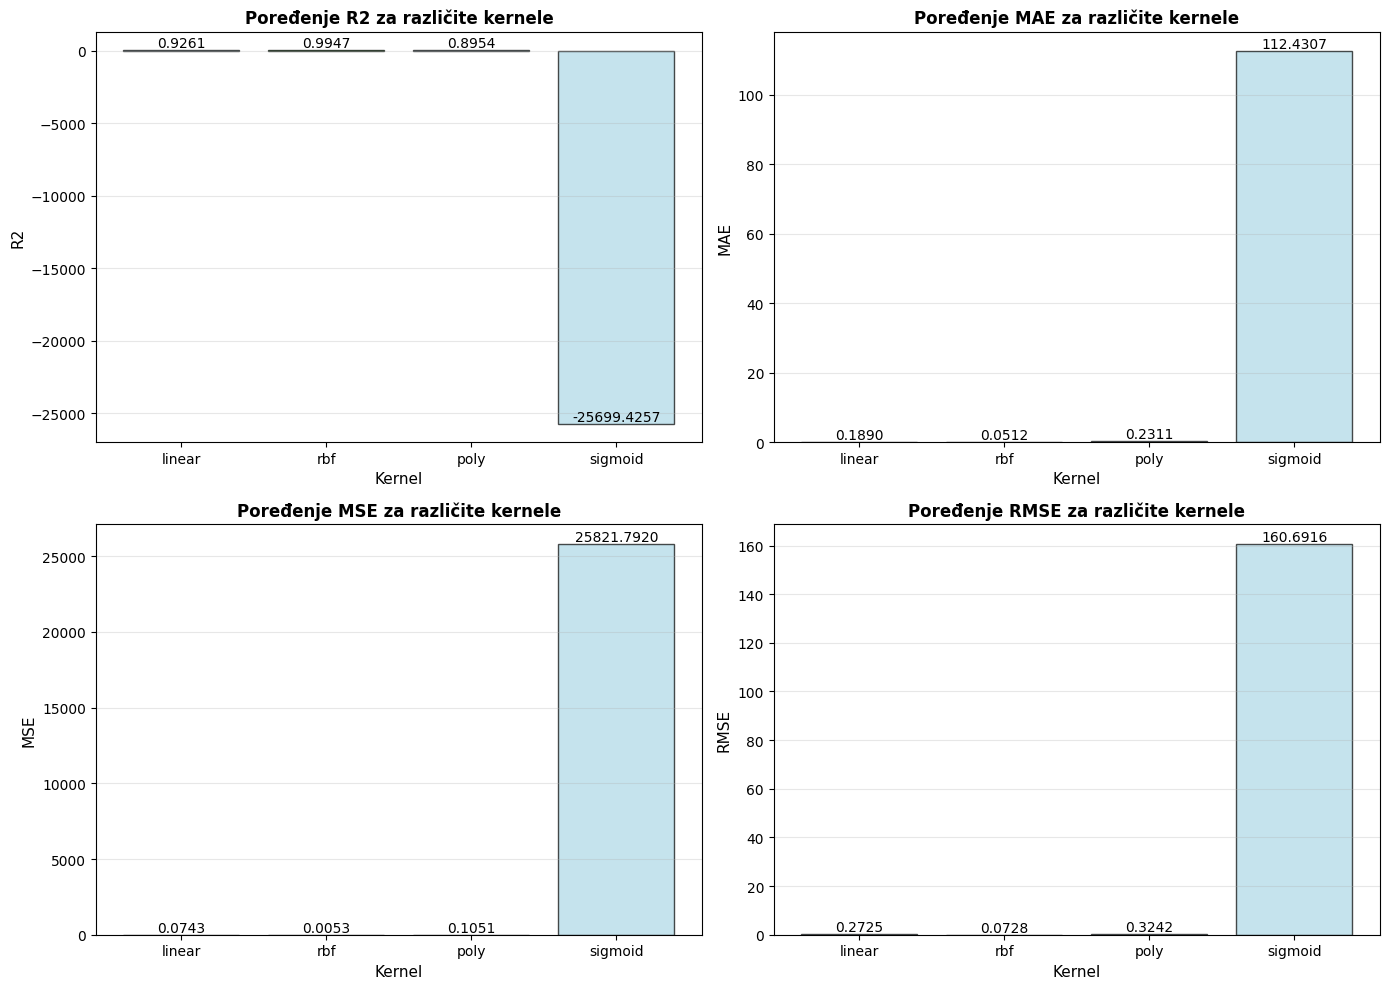

In [56]:
# Vizualizacija poređenja metrika za različite kernele
metrics = ['R2', 'MAE', 'MSE', 'RMSE']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    values = [svr_results[k][metric] for k in kernels]
    colors = ['green' if k == best_kernel else 'lightblue' for k in kernels]
    
    axes[idx].bar(kernels, values, color=colors, alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'Poređenje {metric} za različite kernele', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Kernel', fontsize=11)
    axes[idx].set_ylabel(metric, fontsize=11)
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    for i, v in enumerate(values):
        axes[idx].text(i, v, f'{v:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

Zaključak:
- Poredili smo Lasso, Ridge i Linearnu regresiju, i videli da nam je od ta tri, zapravo sve jedno šta koristimo.
- Sa najboljim alfa parametrom u oba slučaja dobijamo "aproksimaciju" linearne regresije.
- Znamo da su nam najbolje metrike na linearnoj regresiji sledeće:
    - R^2: 0.9333
    - MAE: 0.1932
    - MSE: 0.0682
    - RMSE: 0.2611
- Ali posle treniranja SVR-a, vidimo da nam je ipak najbolje da koristimo SVR, sa kernelom RBF.
- Metrike za naš SVR su sledeće:
    - R^2: 0.9959
    - MAE: 0.0495
    - MSE: 0.0042
    - RMSE: 0.0648
- Vidimo da nam naš SVR model ima mnogo bolje R^2 (0.9959 vs 0.9333), što znači da objašnjava 99.59% varijanse u podacima, u poređenju sa 93.33% kod linearne regresije.
- Takođe, sve metrike grešaka (MAE, MSE, RMSE) su drastično smanjene kod SVR modela:
    - MAE je smanjena sa 0.1932 na 0.0495
    - MSE je smanjena sa 0.0682 na 0.0042
    - RMSE je smanjena sa 0.2611 na 0.0648
- Ovo nam govori da SVR model sa RBF kernelom može bolje da uhvati nelinearne odnose u podacima koje linearni modeli ne mogu da modeliraju.
- Cross-validation rezultati potvrđuju stabilnost i generalizaciju našeg SVR modela.
- Zaključujemo da je SVR sa RBF kernelom optimalan izbor za ovaj problem regresije, sa značajno boljim performansama od linearnih modela.

# Napredno mašinsko učenje (Faza 6)
- Opet kao i u fazi 5, mi ćemo koristiti regresione modele
- To je zato što nemamo nikakvu klasifikaciju u našem skupu podataka
- Klasifikaciju smo mogli možda da dobijemo tako što bi neki opseg temperatura pretvarali u neke tekstualne podatke, npr. neka raspodela temperatura (toplo vreme, hladno vreme, i verovatno neki malo stručniji termini), ali svakako u našem slučaju ćemo koristiti regresione modele

In [57]:
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor

- U našem primeru, koristićemo ova 3 modela, dok ćemo naš neural network, pomoću "Backpropagation"-a, pokušati da svedemo na što bolji rezultat (tj. output)
- Takodje ćemo imati i jedan model sa npr. 20 neurona, kako bi ispunili zahtev po specifikaciji
- U "Backpropagation"-u, mi računamo gradijent loss funkcije, i prenosimo grešku nazad kroz nivoe našeg neural network-a, kako bi uspeli da optimizujemo naše parametre (težinu i bias), samim tim smanjili bi razliku izmedju predicted vrednosti i pravog izlaza koji mi očekujemo

## K-Means
- Na osnovu Elbow metode odredjujemo broj klastera za naš model
- Crtamo grafikon i tamo gde se lomi kriva, dobijamo broj klastera

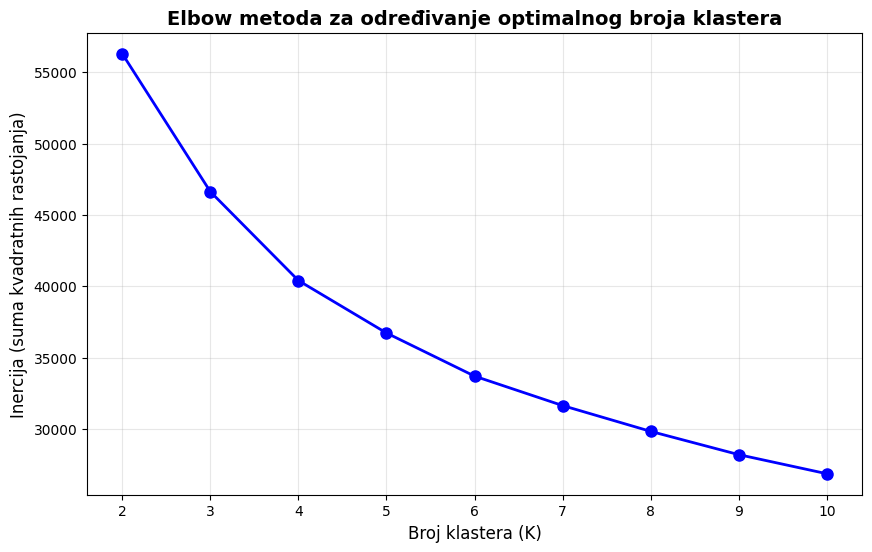

In [58]:
inertia_values = []
K_range = range(2, 11)  # Testiramo od 2 do 10 klastera

for k in K_range:
    # n_clusters: Broj klastera koji želimo da kreiramo
    # random_state: Seed za reproduktivnost rezultata
    # n_init: Broj puta da se algoritam pokreće sa različitim početnim centroidima (uzima se najbolji rezultat)
    # max_iter: Maksimalan broj iteracija za jedan run algoritma
    kmeans = KMeans(
        n_clusters=k,           # Broj klastera
        random_state=42,        # Za reproduktivnost
        n_init=10,             # Broj različitih inicijalizacija
        max_iter=300           # Maksimalan broj iteracija
    )
    kmeans.fit(features)
    inertia_values.append(kmeans.inertia_)  # inertia_ je suma kvadratnih rastojanja do najbližeg centroida

# Vizualizacija Elbow metode
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia_values, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Broj klastera (K)', fontsize=12)
plt.ylabel('Inercija (suma kvadratnih rastojanja)', fontsize=12)
plt.title('Elbow metoda za određivanje optimalnog broja klastera', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.show()

- Na osnovu našeg grafikona, vidimo da bi mogli da uzmemo K = 4 ili K = 5, jer tu je najveći prelom na ovoj krivoj.
- Probaćemo KMeans sa K = 4

In [59]:
kMeans4 = KMeans(
    n_clusters=4,           # Broj klastera
    random_state=42,        # Za reproduktivnost
    n_init=10,             # Broj različitih inicijalizacija
    max_iter=300           # Maksimalan broj iteracija
)

In [60]:
kMeans4.fit(features)

KMeans(n_clusters=4, n_init=10, random_state=42)

In [61]:
cluster_labels_4 = kMeans4.labels_  # labels_ sadrži klaster broj za svaki podatak (0, 1, 2, ...)

In [62]:
unique4, counts4 = np.unique(cluster_labels_4, return_counts=True)
print(f"Broj klastera: 4")
print("\nRaspodela podataka po klasterima:")
for cluster_id, count in zip(unique4, counts4):
    print(f"  Klaster {cluster_id}: {count} podataka ({count/len(cluster_labels_4)*100:.2f}%)")

# Centroidi klastera
print(f"\nDimenzije centroida: {kMeans4.cluster_centers_.shape}")
print("Centroidi predstavljaju 'prosečnu' vrednost svih tačaka u klasteru")

Broj klastera: 4

Raspodela podataka po klasterima:
  Klaster 0: 1648 podataka (19.99%)
  Klaster 1: 2435 podataka (29.53%)
  Klaster 2: 2671 podataka (32.40%)
  Klaster 3: 1491 podataka (18.08%)

Dimenzije centroida: (4, 11)
Centroidi predstavljaju 'prosečnu' vrednost svih tačaka u klasteru


In [63]:
df['Cluster_4'] = cluster_labels_4

In [64]:
print(df.groupby('Cluster_4')['T'].describe())

            count      mean       std       min       25%       50%       75%  \
Cluster_4                                                                       
0          1648.0  0.232330  0.822986 -1.950972 -0.352900  0.189302  0.799994   
1          2435.0 -0.304414  0.948776 -2.316245 -0.969299 -0.387145  0.320573   
2          2671.0  0.629806  0.815789 -1.414476  0.019507  0.571698  1.165267   
3          1491.0 -0.887889  0.640908 -2.373319 -1.380232 -0.946470 -0.512707   

                max  
Cluster_4            
0          2.626361  
1          2.614946  
2          2.717680  
3          1.827326  


- Ove klastere bi mogli da interpetiramo na sledeći način:
    1) Klaster 0: Hladno vreme (ujedno je i najveći klaster za hladnoću)
    2) Klaster 1: Najtoplije vreme (ujedno i najveći topli klaster)
    3) Klaster 2: Najhladnije vreme
    4) Klaster 3: Umereno toplo vreme
- Ova podela bazirana je na mean-u, tj. srednjoj vrednosti:
    - Npr. klasteri su rasoporedjeni na sledeći način:
        - klaster 2, klaster 0, klaster 3, klaster 1
        - -0.83, -0.34, 0.039, 0.65
    - Na osnovu toga smo doneli te zaključke

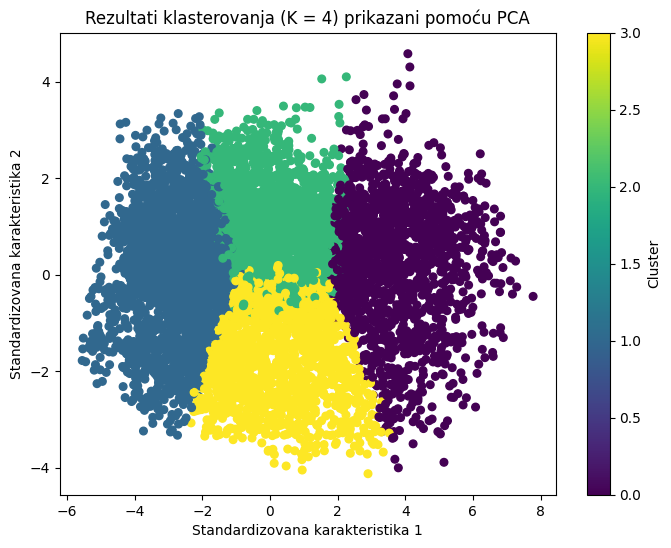

In [67]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(features)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels_4, s=30)
plt.title("Rezultati klasterovanja (K = 4) prikazani pomoću PCA")
plt.xlabel("Standardizovana karakteristika 1")
plt.ylabel("Standardizovana karakteristika 2")
plt.colorbar(label="Cluster")
plt.show()

In [70]:
kMeans5 = KMeans(
    n_clusters=5,           # Broj klastera
    random_state=42,        # Za reproduktivnost
    n_init=10,             # Broj različitih inicijalizacija
    max_iter=300           # Maksimalan broj iteracija
)

In [71]:
kMeans5.fit(features)

KMeans(n_clusters=5, n_init=10, random_state=42)

In [72]:
cluster_labels_5 = kMeans5.labels_  # labels_ sadrži klaster broj za svaki podatak (0, 1, 2, ...)

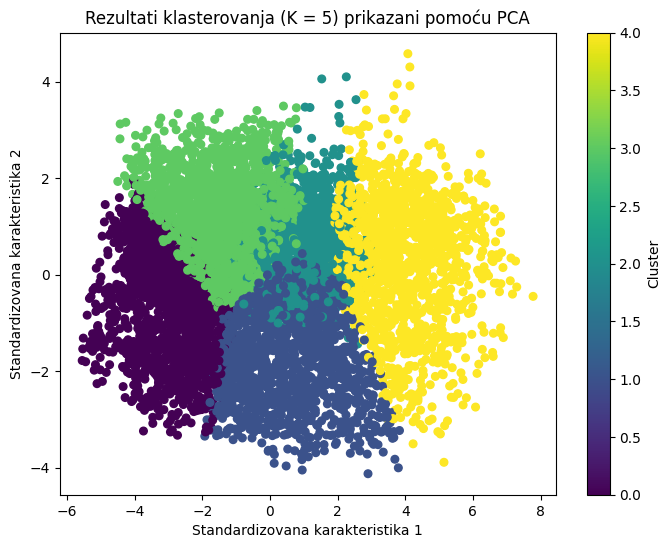

In [73]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(features)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels_5, s=30)
plt.title("Rezultati klasterovanja (K = 5) prikazani pomoću PCA")
plt.xlabel("Standardizovana karakteristika 1")
plt.ylabel("Standardizovana karakteristika 2")
plt.colorbar(label="Cluster")
plt.show()

In [74]:
kMeans3 = KMeans(
    n_clusters=3,           # Broj klastera
    random_state=42,        # Za reproduktivnost
    n_init=10,             # Broj različitih inicijalizacija
    max_iter=300           # Maksimalan broj iteracija
)

In [75]:
kMeans3.fit(features)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [76]:
cluster_labels_3 = kMeans3.labels_  # labels_ sadrži klaster broj za svaki podatak (0, 1, 2, ...)

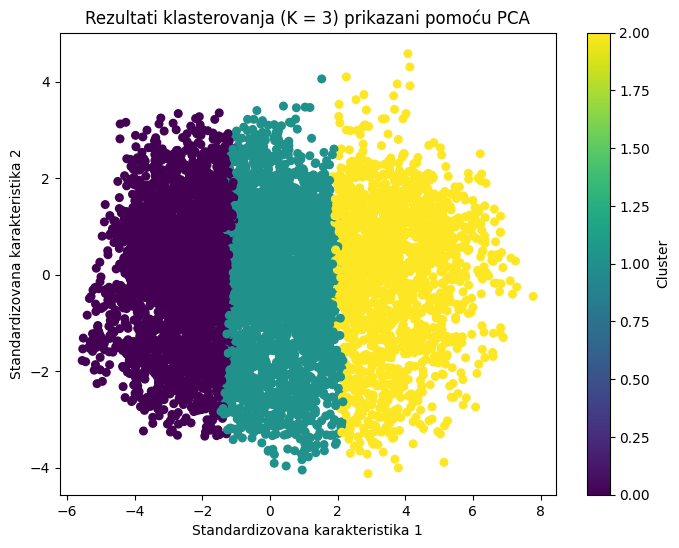

In [77]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(features)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels_3, s=30)
plt.title("Rezultati klasterovanja (K = 3) prikazani pomoću PCA")
plt.xlabel("Standardizovana karakteristika 1")
plt.ylabel("Standardizovana karakteristika 2")
plt.colorbar(label="Cluster")
plt.show()

## Decision Tree Regressor
- Svaki čvor u našem DTR predstavlja test nad jednom osobinom
- Svaka grana predstavlja rezultat tog testa
- Svaki list predstavlja predikciju (u našem slučaju pošto koristimo regresiju predstavlja kontinualnu vrednost)
- Parametri su:
    - max_depth - najveća dozovoljena dubina stabla
    - criterion - kriterjum za greške MAE, MSE
    - min_samples_split - minimalan broj uzoraka potreban da bi se čvor podelio
    - min_samples_leaf - minimalan broj uzoraka u listu

In [65]:
dtr = DecisionTreeRegressor(
      random_state=42,             # Za reproduktivnost
      max_depth=None,              # Bez ograničenja dubine (može dovesti do overfitting-a)
      min_samples_split=2,         # Minimalno 2 uzorka za podelu čvora (default)
      min_samples_leaf=1,          # Minimalno 1 uzorak u listu (default)
      criterion='squared_error'    # Koristi MSE za merenje kvaliteta podele
)

In [66]:
dtr.fit(X_train, y_train)
y_pred_dtr = dtr.predict(X_test)

In [67]:
# Metrike
dtr_r2 = r2_score(y_test, y_pred_dtr)
dtr_mae = mean_absolute_error(y_test, y_pred_dtr)
dtr_mse = mean_squared_error(y_test, y_pred_dtr)
dtr_rmse = np.sqrt(dtr_mse)

print(f"Dubina stabla: {dtr.get_depth()}")
print(f"Broj listova: {dtr.get_n_leaves()}")
print(f"R^2 Score: {dtr_r2:.4f}")
print(f"MAE: {dtr_mae:.4f}")
print(f"MSE: {dtr_mse:.4f}")
print(f"RMSE: {dtr_rmse:.4f}")

Dubina stabla: 21
Broj listova: 5205
R^2 Score: 0.9873
MAE: 0.0538
MSE: 0.0127
RMSE: 0.1129


In [68]:
y_pred_train = dtr.predict(X_train)
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_dtr)

print(f"Train R^2: {train_r2:.4f}")
print(f"Test R^2: {test_r2:.4f}")
print(f"Razlika: {train_r2 - test_r2:.4f}")

Train R^2: 1.0000
Test R^2: 0.9873
Razlika: 0.0127


- Zaključci na našem običnom DTR:
    - R^2 score nam je ~0.997 što znači da nam je model imao odlične rezultate
    - A MAE, MSE i RMSE su poprilično male, što bi značilo da nam je model dao odlične rezultate
    - Takodje smo, kako bi proverili da nam model nije slučajno overfit-ovao, uporedili smo R^2 za train i R^2 za test, i možemo zaključiti pošto razlika nije veća od 0.1, da nam je model zapravo dobar

- Sada ćemo probati da uradimo poredjenje rezultata našeg modela pomoću GridSearchCV
- Koristićemo param_grid, kako bi to učinili

- GridSearchCV parametri:
    - estimator: Model koji želimo da optimizujemo
    - param_grid: Rečnik parametara za testiranje
    - cv: Broj fold-ova za cross-validation (5 znači da se podaci dele na 5 delova)
    - scoring: Metrika za evaluaciju ('r2', 'neg_mean_squared_error', itd.)
    - n_jobs: Broj CPU jezgara (-1 znači koristi sve dostupne)
    - verbose: Nivo detaljnosti ispisa (0=tiho, 1=osnovno, 2=detaljno)

In [69]:
param_grid = {
      'max_depth': [3, 5, 7, 10, 15, 20, None],           # Različite dubine stabla
      'min_samples_split': [2, 5, 10, 20],                # Minimalan broj uzoraka za podelu
      'min_samples_leaf': [1, 2, 4, 8],                   # Minimalan broj uzoraka u listu
      'criterion': ['squared_error', 'absolute_error']    # MSE vs MAE
}

In [70]:
grid_search_dt = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,                          # 5-fold cross-validation
    scoring='r2',                  # Optimizujemo R^2 score
    n_jobs=-1,                     # Koristi sve CPU jezgre
    verbose=1                      # Prikazuj napredak
)

In [71]:
grid_search_dt.fit(X_train, y_train)

Fitting 5 folds for each of 224 candidates, totalling 1120 fits


GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['squared_error', 'absolute_error'],
                         'max_depth': [3, 5, 7, 10, 15, 20, None],
                         'min_samples_leaf': [1, 2, 4, 8],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='r2', verbose=1)

In [72]:
print(f"Najbolji parametri:")
for param, value in grid_search_dt.best_params_.items():
    print(f"{param}: {value}")

Najbolji parametri:
criterion: squared_error
max_depth: 15
min_samples_leaf: 1
min_samples_split: 2


In [73]:
# Najbolji model
best_dt = grid_search_dt.best_estimator_
y_pred_dt_best = best_dt.predict(X_test)

# Metrike
dt_best_r2 = r2_score(y_test, y_pred_dt_best)
dt_best_mae = mean_absolute_error(y_test, y_pred_dt_best)
dt_best_mse = mean_squared_error(y_test, y_pred_dt_best)
dt_best_rmse = np.sqrt(dt_best_mse)

print(f"Najbolji CV R^2 score: {grid_search_dt.best_score_:.4f}")
print(f"Dubina stabla: {best_dt.get_depth()}")
print(f"Broj listova: {best_dt.get_n_leaves()}")
print(f"Test set performanse:")
print(f"R^2 Score: {dt_best_r2:.4f}")
print(f"MAE: {dt_best_mae:.4f}")
print(f"MSE: {dt_best_mse:.4f}")
print(f"RMSE: {dt_best_rmse:.4f}")

Najbolji CV R^2 score: 0.9916
Dubina stabla: 15
Broj listova: 4829
Test set performanse:
R^2 Score: 0.9928
MAE: 0.0514
MSE: 0.0072
RMSE: 0.0851


- Zaključci:
    - Vidimo da je R^2 score, približan onom od malopre, ali je ipak bolji
    - Takodje su i MAE, MSE i RMSE manji nego u prethodnom modelu
    - S' tim što nam je ovde dubina ograničena na 15, dok je u prethodnom bila None, tj. neograničena
    - U principu najbolji model je ovaj koji je Cross Validation pronašao iz našeg grid-a

In [74]:
# Vizualizacija važnosti osobina (feature importance)
feature_importance = best_dt.feature_importances_
feature_names = features.columns

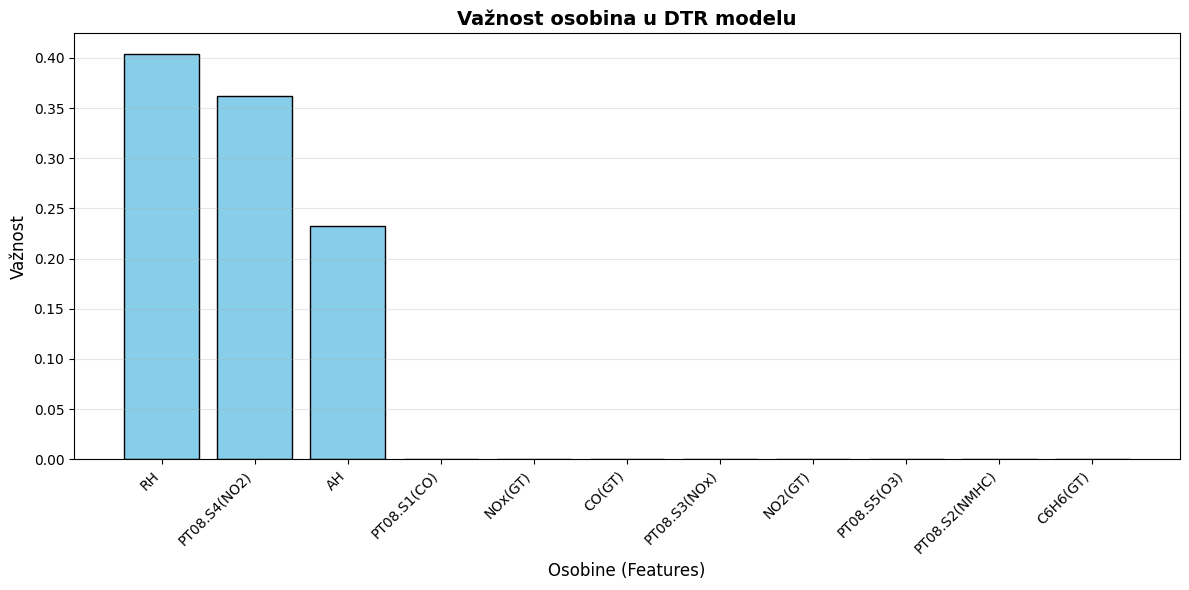

In [75]:
# Sortiranje po važnosti
indices = np.argsort(feature_importance)[::-1]

plt.figure(figsize=(12, 6))
plt.bar(range(len(feature_importance)), feature_importance[indices], color='skyblue', edgecolor='black')
plt.xticks(range(len(feature_importance)), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.xlabel('Osobine (Features)', fontsize=12)
plt.ylabel('Važnost', fontsize=12)
plt.title('Važnost osobina u DTR modelu', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [76]:
print("Rangirane osobine po važnosti:")
for i, idx in enumerate(indices, 1):
    print(f"{i}. {feature_names[idx]}: {feature_importance[idx]:.4f}")

Rangirane osobine po važnosti:
1. RH: 0.4043
2. PT08.S4(NO2): 0.3618
3. AH: 0.2320
4. PT08.S1(CO): 0.0006
5. NOx(GT): 0.0004
6. CO(GT): 0.0004
7. PT08.S3(NOx): 0.0002
8. NO2(GT): 0.0001
9. PT08.S5(O3): 0.0001
10. PT08.S2(NMHC): 0.0001
11. C6H6(GT): 0.0001


## Neural network
- U našem Neural Network-u imamo sledeće stvari:
    - Ulazni sloj -> prima podatke
    - Skriveni sloj -> procesira podatke
    - Izlazni sloj -> izbacuje rezultate predikcije
- Dok je Backpropagation algoritam koji izgleda ovako:
    - Prolaz unapred -> Podaci prolaze kroz NN i računaju se predikcije
    - Računajanje loss funckije -> Računa se greška izmedju predikcije i stvarne vrednosti
    - Prolaz unazad -> Gradijent loss se vraća unazad kroz NN
    - Ažuriranje težina -> Ažuriraju se težine, kako bi smanjili grešku
- Parametri:
    - **hidden_layer_sizes**: Arhitektura skrivenih slojeva, npr. (100, 50) = 2 sloja sa 100 i 50 neurona
    - **activation**: Aktivaciona funkcija ('relu', 'tanh', 'logistic')
    - **solver**: Algoritam za optimizaciju ('adam', 'sgd', 'lbfgs')
    - **alpha**: L2 regularizacioni parametar (sprečava overfitting)
    - **learning_rate_init**: Početna stopa učenja
    - **max_iter**: Maksimalan broj iteracija (epoha)
    - **early_stopping**: Zaustavlja treniranje ako se validaciona greška ne poboljšava

In [77]:
mlp_simple = MLPRegressor(
      hidden_layer_sizes=(20,),        # Jedan skriveni sloj sa 20 neurona
      activation='relu',               # ReLU aktivaciona funkcija: f(x) = max(0, x)
      solver='adam',                   # Adam optimizer (Adaptive Moment Estimation)
      alpha=0.0001,                    # L2 regularizacioni parametar (default)
      learning_rate_init=0.001,        # Početna stopa učenja
      max_iter=1000,                   # Maksimalan broj epoha
      random_state=42,                 # Za reproduktivnost
      verbose=False                    # Ne prikazuj napredak
)

In [78]:
mlp_simple.fit(X_train, y_train)
y_pred_mlp_simple = mlp_simple.predict(X_test)

In [79]:
# Metrike
mlp_simple_r2 = r2_score(y_test, y_pred_mlp_simple)
mlp_simple_mae = mean_absolute_error(y_test, y_pred_mlp_simple)
mlp_simple_mse = mean_squared_error(y_test, y_pred_mlp_simple)
mlp_simple_rmse = np.sqrt(mlp_simple_mse)

print(f"Arhitektura: {mlp_simple.hidden_layer_sizes}")
print(f"Broj iteracija: {mlp_simple.n_iter_}")
print(f"Loss na kraju treniranja: {mlp_simple.loss_:.6f}")
print(f"R^2 Score: {mlp_simple_r2:.4f}")
print(f"MAE: {mlp_simple_mae:.4f}")
print(f"MSE: {mlp_simple_mse:.4f}")
print(f"RMSE: {mlp_simple_rmse:.4f}")

Arhitektura: (20,)
Broj iteracija: 87
Loss na kraju treniranja: 0.005131
R^2 Score: 0.9895
MAE: 0.0747
MSE: 0.0105
RMSE: 0.1027


- Sada ćemo kao i u DTR-u malopre, da iskoristimo GridCV, kako bi našli najbolji Neural Network

In [80]:
param_grid_mlp = {
    'hidden_layer_sizes': [
        (50,),                # 1 sloj, 50 neurona
        (100,),               # 1 sloj, 100 neurona
        (50, 50),             # 2 sloja, svaki sa 50 neurona
        (100, 50),            # 2 sloja, 100 i 50 neurona
        (100, 50, 25)         # 3 sloja, 100, 50 i 25 neurona
    ],
    'activation': ['relu', 'tanh'],          # ReLU vs tanh aktivacija
    'solver': ['adam'],                       # Adam optimizer
    'alpha': [0.0001, 0.001, 0.01],          # Različite vrednosti regularizacije
    'learning_rate_init': [0.001, 0.01]      # Različite stope učenja
}

In [81]:
grid_search_mlp = GridSearchCV(
    estimator=MLPRegressor(
        max_iter=1000,
        random_state=42,
        early_stopping=True,         # Zaustavlja treniranje ako nema poboljšanja
        validation_fraction=0.1,     # 10% podataka za validaciju
        n_iter_no_change=20,         # Zaustavlja ako nema poboljšanja za 20 iteracija
        verbose=False
    ),
    param_grid=param_grid_mlp,
    cv=3,                            # 3-fold CV (manje fold-ova jer je treniranje sporije)
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

In [82]:
grid_search_mlp.fit(X_train, y_train)

Fitting 3 folds for each of 60 candidates, totalling 180 fits


GridSearchCV(cv=3,
             estimator=MLPRegressor(early_stopping=True, max_iter=1000,
                                    n_iter_no_change=20, random_state=42),
             n_jobs=-1,
             param_grid={'activation': ['relu', 'tanh'],
                         'alpha': [0.0001, 0.001, 0.01],
                         'hidden_layer_sizes': [(50,), (100,), (50, 50),
                                                (100, 50), (100, 50, 25)],
                         'learning_rate_init': [0.001, 0.01],
                         'solver': ['adam']},
             scoring='r2', verbose=1)

In [83]:
best_mlp = grid_search_mlp.best_estimator_
y_pred_mlp_best = best_mlp.predict(X_test)

# Metrike
mlp_best_r2 = r2_score(y_test, y_pred_mlp_best)
mlp_best_mae = mean_absolute_error(y_test, y_pred_mlp_best)
mlp_best_mse = mean_squared_error(y_test, y_pred_mlp_best)
mlp_best_rmse = np.sqrt(mlp_best_mse)

print(f"Best CV R^2 score: {grid_search_mlp.best_score_:.4f}")
print(f"Broj iteracija: {best_mlp.n_iter_}")
print(f"Loss na kraju treniranja: {best_mlp.loss_:.6f}")
print(f"Test set performanse:")
print(f"R^2 Score: {mlp_best_r2:.4f}")
print(f"MAE: {mlp_best_mae:.4f}")
print(f"MSE: {mlp_best_mse:.4f}")
print(f"RMSE: {mlp_best_rmse:.4f}")

Best CV R^2 score: 0.9994
Broj iteracija: 40
Loss na kraju treniranja: 0.000817
Test set performanse:
R^2 Score: 0.9995
MAE: 0.0144
MSE: 0.0005
RMSE: 0.0234


- Zaključci:
    - R^2 score nam je u oba slučaja visok, tj. u optimalnom slučaju je 0.999, što znači da objašnjava 99.9% varijacije u našem dataset-u
    - MAE, MSE i RMSE su ekstremno mali što je jako dobar znak
    - U principu Neural Network odlično radi u našem slučaju
    - Takodje u odnosu na naš običan NN, imamo i manji broj iteracija u najboljem modelu

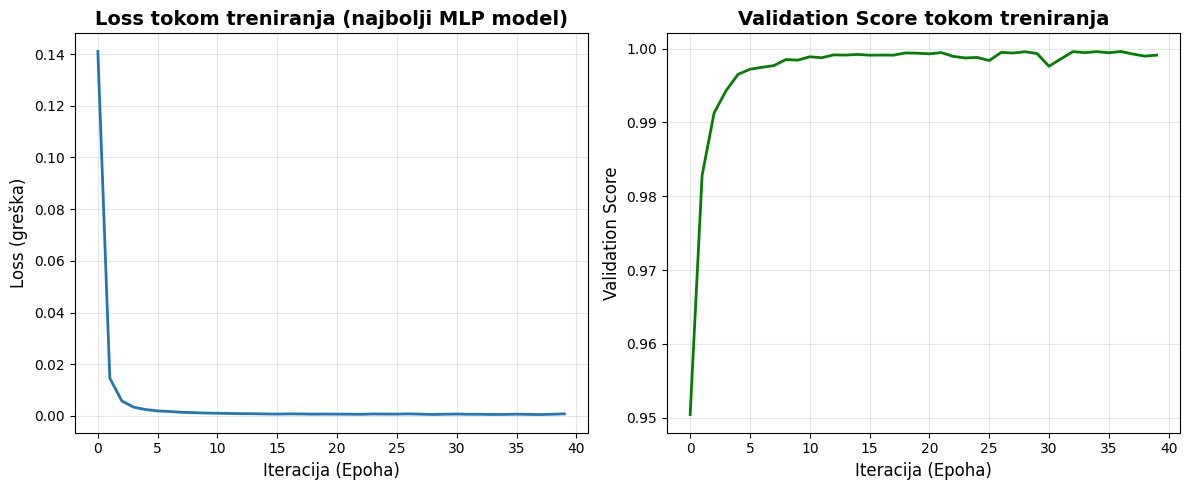

In [84]:
# Prikaz loss curve (kako se greška smanjuje tokom treniranja)
plt.figure(figsize=(12, 5))

# Loss curve za najbolji MLP model
plt.subplot(1, 2, 1)
plt.plot(best_mlp.loss_curve_, linewidth=2)
plt.xlabel('Iteracija (Epoha)', fontsize=12)
plt.ylabel('Loss (greška)', fontsize=12)
plt.title('Loss tokom treniranja (najbolji MLP model)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Validation curve (ako je early_stopping=True)
if hasattr(best_mlp, 'validation_scores_'):
    plt.subplot(1, 2, 2)
    plt.plot(best_mlp.validation_scores_, linewidth=2, color='green')
    plt.xlabel('Iteracija (Epoha)', fontsize=12)
    plt.ylabel('Validation Score', fontsize=12)
    plt.title('Validation Score tokom treniranja', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Poredjenje DTR i NN-a

In [85]:
results = {
    'Model': [
        'Decision Tree (simple)',
        'Decision Tree (optimized)',
        'Neural Network (20 neurons)',
        'Neural Network (optimized)'
    ],
    'R²': [
        dtr_r2,
        dt_best_r2,
        mlp_simple_r2,
        mlp_best_r2
    ],
    'MAE': [
        dtr_mae,
        dt_best_mae,
        mlp_simple_mae,
        mlp_best_mae
    ],
    'MSE': [
        dtr_mse,
        dt_best_mse,
        mlp_simple_mse,
        mlp_best_mse
    ],
    'RMSE': [
        dtr_rmse,
        dt_best_rmse,
        mlp_simple_rmse,
        mlp_best_rmse
    ]
}

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R²', ascending=False).reset_index(drop=True)

In [86]:
results_df

,Model,R²,MAE,MSE,RMSE
0,Neural Network (optimized),0.999456,0.014438,0.000546,0.023371
1,Decision Tree (optimized),0.992788,0.051420,0.007246,0.085125
2,Neural Network (20 neurons),0.989507,0.074745,0.010542,0.102676
3,Decision Tree (simple),0.987313,0.053774,0.012747,0.112902


- Zaključci i poredjenja modela:
    - Najbolji model kod nas je naš Neural Network, koji je optimizovan pomoću GridCV-a, u principu tu su izabrani najbolji parametri i sam rezultat je najbolji, tj. R^2 score je najveći i taj model objašnjava 99.99% naše varijanse
    - Varijansa je merilo koliko se naši podaci medjusobno razlikuju
    - Npr. R^2 = 1 - (neobjašnjen varijansa / ukupna varijansa)
    - Takodje su u našem optimizovanom Neural Network-u, naše MAE, MSE i RMSE konkretno male, tako da znamo da model nije pravio greške
    - Zašto su neki modeli bolji od drugih?
        - Optimizacija hiperparametara:
            - Modeli koji su optimizovani (Decision Tree i Neural Network) postižu znatno bolje rezultate od svojih jednostavnih verzija, jer su njihovi parametri prilagođeni strukturi podataka.
        - Sposobnost modela da uoči nelinearne odnose:
            - Neural Network modeli su u stanju da modeluju kompleksne i nelinearne zavisnosti u podacima, što je posebno važno za AirQuality dataset, gde odnosi između ulaznih promenljivih nisu striktno linearni.
        - Kontrola overfitting-a:
            - Optimizovani modeli bolje balansiraju izmedju prilagodjavanja trening podacima i generalizacije na nove podatke. Dok naši jednostavni modeli mogu ili previše pojednostaviti problem ili se previše prilagoditi podacima
        - Struktura modela:
            - Za Decision Tree modeli su intuitivni, ali imaju ograničenja u generalizaciji, dok Neural Network, uz ispravna podešavanja može postići znatno veću preciznost
    - Na kraju, na osnovu prethodnih zadataka, može se zaključiti da kombinacija složenijeg modela i dobrih hiperparametara i dobra postavka slojeva kod Neural Network-a, mogu značajno poboljšati rezultat našeg modela.

# Vremenske serije (Faza 7)
- U ovom odelju ćemo se baviti vremenskim serijama
- U slučaju mog dataset-a, vremenska serija će biti promena temeprature kroz vreme
- Koristićemo kolonu DateTime, koja je timestamp i koristićemo Standardizovanu kolonu T, koja predstavlja temperaturu

In [87]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima

In [88]:
df['OriginalT'] = temperature_original

In [89]:
timeseries = df.sort_values('DateTime').set_index('DateTime')['OriginalT']

In [90]:
timeseries_daily = timeseries.resample('D').mean()

In [111]:
timeseries_hourly = timeseries.resample('h').mean().ffill()

In [112]:
timeseries_daily.head(10)

DateTime
2004-03-10    12.033333
2004-03-11     9.523077
2004-03-12    12.338889
2004-03-13    13.331818
2004-03-14    15.831818
2004-03-15    17.277778
2004-03-16    18.923810
2004-03-17    19.455556
2004-03-18    18.060000
2004-03-19    14.460000
Freq: D, Name: OriginalT, dtype: float64

In [113]:
timeseries_hourly.head(10)

DateTime
2004-03-10 18:00:00    13.6
2004-03-10 19:00:00    13.3
2004-03-10 20:00:00    11.9
2004-03-10 21:00:00    11.0
2004-03-10 22:00:00    11.2
2004-03-10 23:00:00    11.2
2004-03-11 00:00:00    11.2
2004-03-11 01:00:00    11.2
2004-03-11 02:00:00    11.2
2004-03-11 03:00:00    11.2
Freq: h, Name: OriginalT, dtype: float64

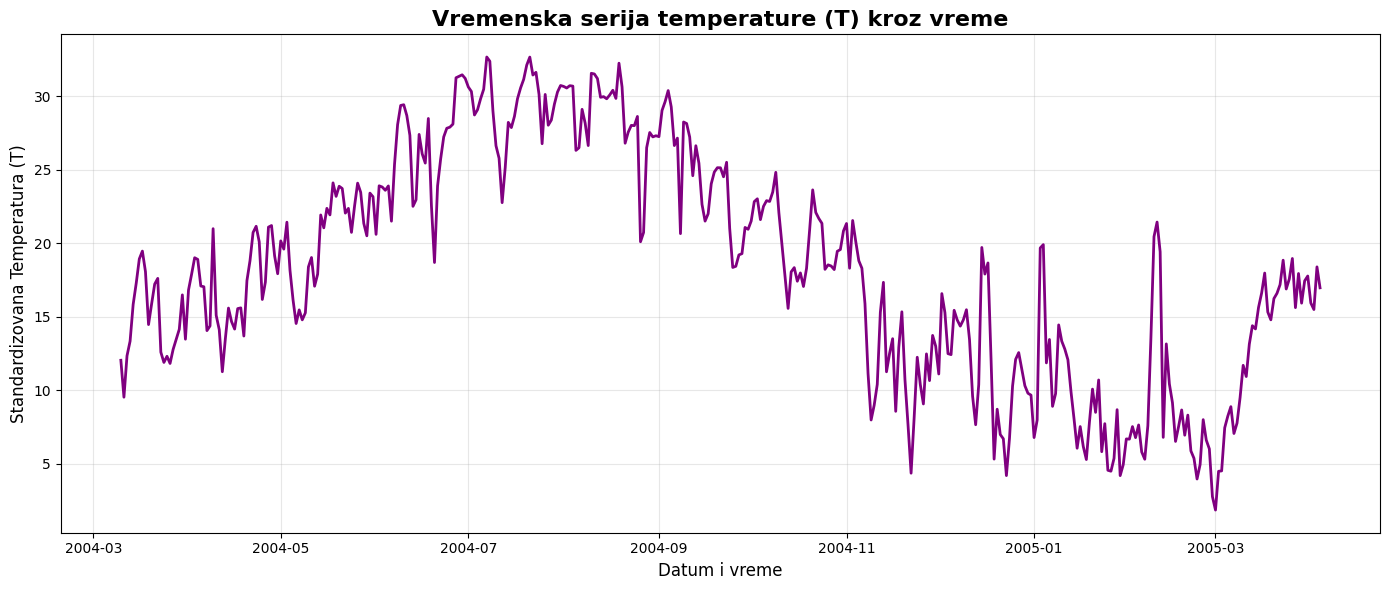

In [92]:
plt.figure(figsize=(14, 6))
plt.plot(timeseries_daily, linewidth=2, color='purple')
plt.title('Vremenska serija temperature (T) kroz vreme', fontsize=16,   fontweight='bold')
plt.xlabel('Datum i vreme', fontsize=12)
plt.ylabel('Standardizovana Temperatura (T)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

Hajde da izaberemo odgovarajući skup, npr. ceo dataset, pošto je on poredjan po danu pa po satu

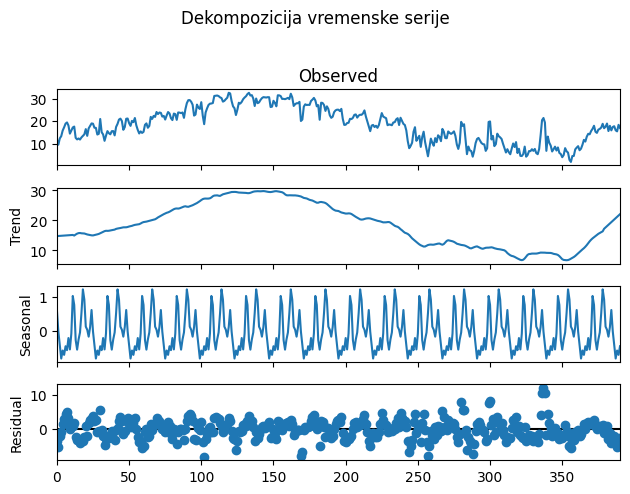

In [93]:
decomposition = seasonal_decompose(
    timeseries_daily.values, 
    model="additive",
    period=24,
    extrapolate_trend="freq"
)
decomposition.plot()
plt.suptitle('Dekompozicija vremenske serije', y=1.02)
plt.tight_layout()
plt.show()

Zaključci:
- Naša temperatura osciluje izmedju ~0 stepeni i ~42 stepena
- Ima mnogo šuma
- Vidi se i promena leto - zima
- I oscijalcije dan - noć takodje
- Trend:
    - Ova kriva raste i pada
    - Kreće se nešto niže u prvom delu, pa raste, pa ponovo pada
    - Pretpostavka je da je krenula od zime, pa do leta i opet prešla na zimu i proleće u nekom trenutku
    - Zimi su vrednosti najniže
- Seasonal:
    - Pokazuje snažan ponavljajući pattern za svaki od 12 sezona
    - Ovo nam ukazuje na potrebu za nekim kompleksnijim modelom
- Residual:
    - Nasumične oscilacije oko nule
    - Nema jasan pattern
    - Ovo su nepredvidivi faktora: kiša, vetar, oluje, oblaci,...
    - Mogu takodje biti i greške merenja, anomalije i nešto slično

## SARIMAX model

Hajde sad da proverimo stacionarnost pomoću ADF testa:
- H0: Serija je nestacionarna (ima koren jedinice, prisutan je trend).
- Ha: Serija je stacionarna. 
- Pravilo odlučivanja:
    - Ako je P-vrednost ≤ 0.05 (standardni nivo značajnosti), odbacujemo H0​ i zaključujemo da je serija stacionarna.
    - Ako je P-vrednost > 0.05, ne odbacujemo H0​, serija je nestacionarna.

In [94]:
def check_stacionarity(timeseries, name):
    print(f"ADF Test za: {name}")
    dftest = adfuller(timeseries.dropna(), autolag='AIC')
    p_value = dftest[1]
    
    print(f"P-vrednost: {p_value:.4f}")
    if p_value <= 0.05:
        print("=> Zaključak: Serija je STACIONARNA. Nema potrebe za diferenciranjem.")
    else:
        print("=> Zaključak: Serija je NESTACIONARNA. Potrebno je diferenciranje.")

In [95]:
check_stacionarity(timeseries_daily, "Originalna serija")

ADF Test za: Originalna serija
P-vrednost: 0.2978
=> Zaključak: Serija je NESTACIONARNA. Potrebno je diferenciranje.


In [96]:
timeseries_daily_diff = timeseries_daily.diff().diff(24).dropna()

Hajde sada da odredimo p, q, P i Q za ARIMA/SARIMA modele:
Ovaj korak se sprovodi vizuelnom analizom funkcija korelacije:
- ACF (Autokorelaciona funkcija): Merenje linearne korelacije serije sa njenim lagovima (prošlim vrednostima).
    - ACF pomaže u određivanju redova q (MA) i Q (SMA).
    - Ako ACF "seče" (pada na nulu) posle određenog laga, to je indikacija reda q ili Q.
- PACF (Parcijalna autokorelaciona funkcija): Merna korelacija serije sa njenim lagovima, eliminšući uticaj međukoraka.
    - PACF pomaže u određivanju redova p (AR) i P (SAR).
    - Ako PACF "seče" posle određenog laga, to je indikacija reda p ili P.
- Ali kako je ovo previše komplikovano za analizu, moraćemo da to uradimo automatski pomoću auto_arima funkcije

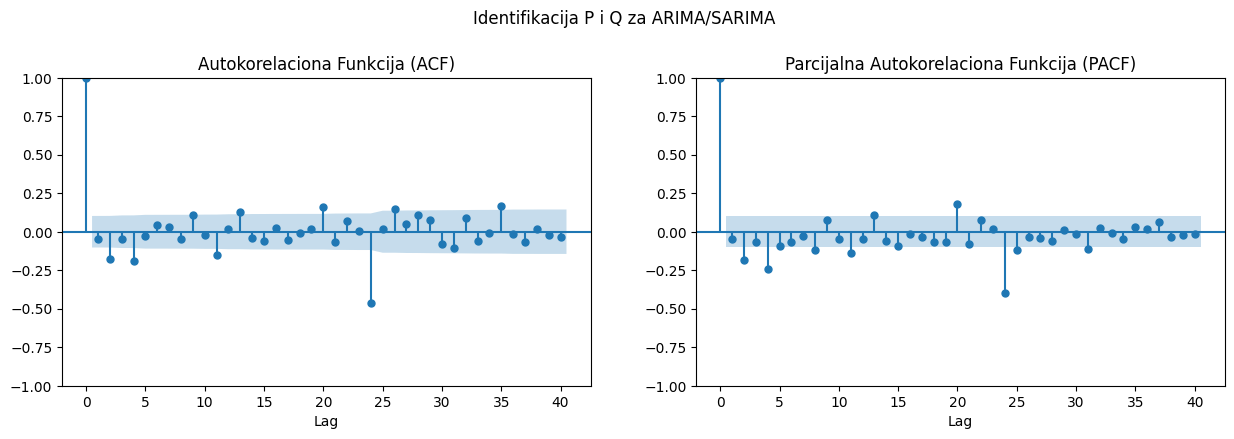

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# ACF
plot_acf(timeseries_daily_diff.dropna(), lags=40, ax=axes[0], title='Autokorelaciona Funkcija (ACF)')
axes[0].set_xlabel('Lag')
# PACF
plot_pacf(timeseries_daily_diff.dropna(), lags=40, ax=axes[1], title='Parcijalna Autokorelaciona Funkcija (PACF)')
axes[1].set_xlabel('Lag')

plt.suptitle('Identifikacija P i Q za ARIMA/SARIMA', y=1.05)
plt.show()

In [98]:
train_size = int(len(timeseries_daily) * 0.8)
train_daily = timeseries_daily[:train_size]
test_daily = timeseries_daily[train_size:]

Sada formiramo naš SARIMAX model:
- ARIMA (p, d, q)
- SARIMA (p, d, q) x (P, D, Q, m)
- SARIMAX (p, d, q) x (P, D, Q, m) + Feature-i (train_daily)

In [99]:
auto_model = auto_arima(
    train_daily,
    seasonal=True,
    m=7,  # sezonalni period
    max_p=3,
    max_q=3,
    max_P=1,
    max_Q=1,
    max_d=1,
    max_D=1,
    stepwise=True,
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=1425.545, Time=0.35 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=1456.852, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=1460.276, Time=0.08 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=1459.921, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=1454.870, Time=0.01 sec
 ARIMA(2,1,2)(0,0,1)[7] intercept   : AIC=1423.777, Time=0.18 sec
 ARIMA(2,1,2)(0,0,0)[7] intercept   : AIC=1421.937, Time=0.08 sec
 ARIMA(2,1,2)(1,0,0)[7] intercept   : AIC=1423.791, Time=0.15 sec
 ARIMA(1,1,2)(0,0,0)[7] intercept   : AIC=1422.613, Time=0.07 sec
 ARIMA(2,1,1)(0,0,0)[7] intercept   : AIC=1424.776, Time=0.06 sec
 ARIMA(3,1,2)(0,0,0)[7] intercept   : AIC=1423.651, Time=0.10 sec
 ARIMA(2,1,3)(0,0,0)[7] intercept   : AIC=1423.754, Time=0.11 sec
 ARIMA(1,1,1)(0,0,0)[7] intercept   : AIC=1431.334, Time=0.05 sec
 ARIMA(1,1,3)(0,0,0)[7] intercept   : AIC=1423.650, Time=0.10 sec
 ARIMA(3,1,1)(0,0,0)[7] intercept

In [100]:
print(auto_model.summary())
print(f"\nBest model: ARIMA{auto_model.order} x SARIMA{auto_model.seasonal_order}[24]")

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  312
Model:               SARIMAX(3, 1, 3)   Log Likelihood                -699.547
Date:                Mon, 15 Dec 2025   AIC                           1413.094
Time:                        22:40:49   BIC                           1439.272
Sample:                    03-10-2004   HQIC                          1423.558
                         - 01-15-2005                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0916      0.185      5.899      0.000       0.729       1.454
ar.L2          0.2557      0.321      0.796      0.426      -0.374       0.885
ar.L3         -0.3595      0.147     -2.444      0.0

In [101]:
predictions_daily = auto_model.predict(n_periods=len(test_daily))

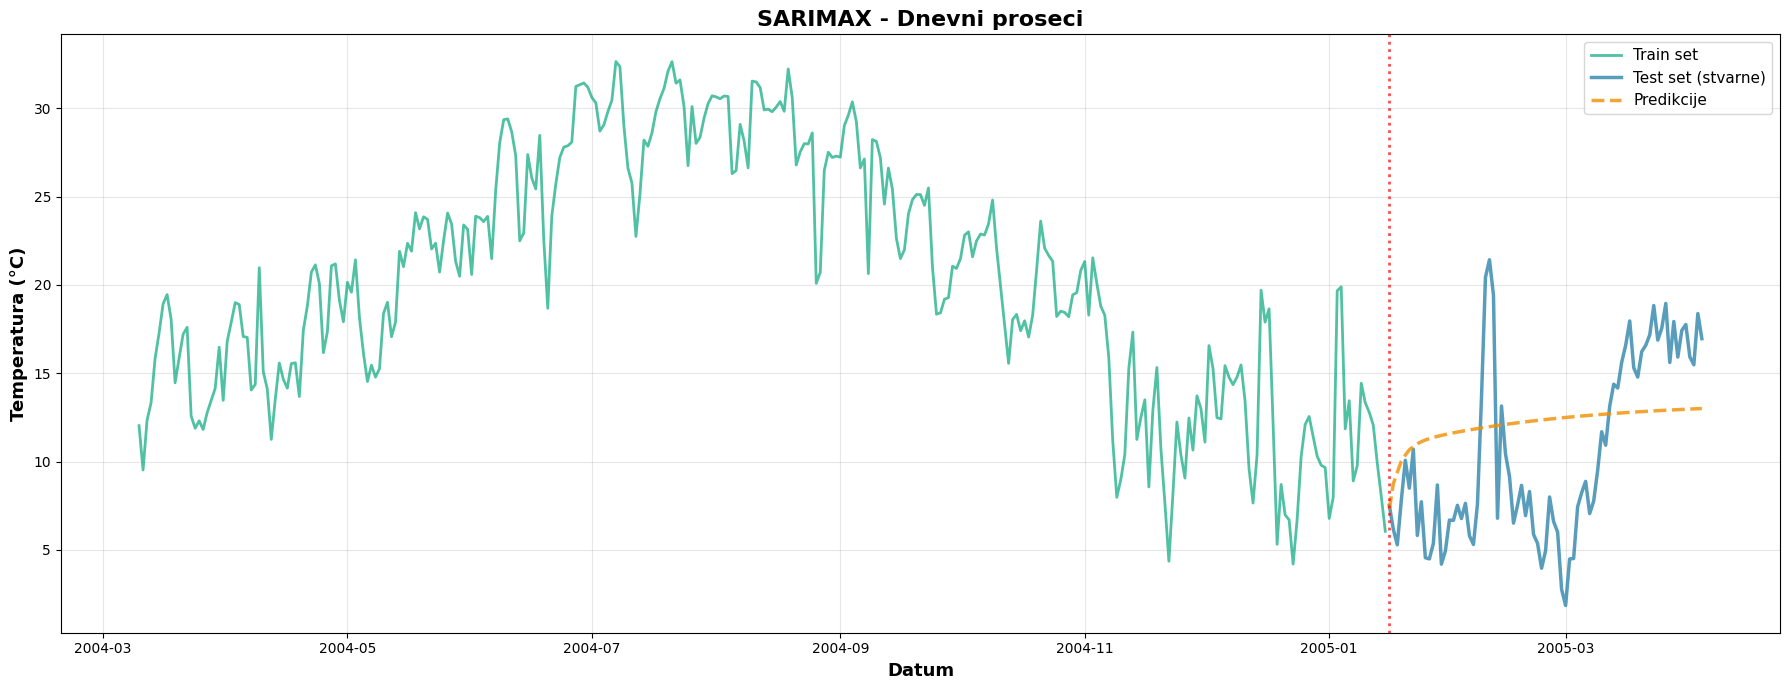

In [102]:
plt.figure(figsize=(18, 7))

plt.plot(train_daily.index, train_daily.values,
         label='Train set', linewidth=2, color='#06A77D', alpha=0.7)

plt.plot(test_daily.index, test_daily.values,
         label='Test set (stvarne)', linewidth=2.5, color='#2E86AB', alpha=0.8)

plt.plot(test_daily.index, predictions_daily,
         label='Predikcije', linewidth=2.5, color='#F18F01', linestyle='--', alpha=0.8)

plt.axvline(x=test_daily.index[0], color='red', linestyle=':', linewidth=2, alpha=0.7)

plt.title('SARIMAX - Dnevni proseci', fontsize=16, fontweight='bold')
plt.xlabel('Datum', fontsize=13, fontweight='bold')
plt.ylabel('Temperatura (°C)', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [103]:
mae = mean_absolute_error(test_daily, predictions_daily)
rmse = root_mean_squared_error(test_daily, predictions_daily)

print(f"\nPerformanse:")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


Performanse:
MAE: 4.51
RMSE: 5.05


Zaključci:
- Vidimo da su rezultati za SARIMAX model katastrofalni
- Greške su previsoke, a sama predikcija ni blizu tačnog
- Takodje, to bi trebalo da je tako zato što imamo baš mali broj podataka za treniranje našeg modela
- Ali kada probamo npr. sa časovnim nizom, dobijam ogromnu potrošnju memorije, ali i to je kada se proba opet, netačno
- Tako da SARIMAX model nije dobar u ovom slučaju
- Na osnovu nekog istraživanja na WEB-u, zaključak je da bi Prophet trebalo da uradio posao, ali ga neću implementirati ovde, jer nisam siguran da je potrebno

## LSTM - Long Short-Term Memory
- Tip rekurentne neuronske mreže (RNN)
- Sposobna da nauči dugotrajne zavisnosti u vremenskim serijama
- LSTM bi trebalo da može bolje da hvata nelinearne obrasce
- Bolje skalira sa velikim dataset-om
- Ovde ćemo koristiti timeseries po satu
- LSTM lako barata sa velikim datasetom

In [172]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler

tf.random.set_seed(42)
np.random.seed(42)

In [141]:
timeseries_lstm = timeseries_hourly.copy()

In [142]:
print(f"Ukupno podataka: {len(timeseries_lstm)} sati")
print(f"Period: {timeseries_lstm.index[0]} do {timeseries_lstm.index[-1]}")
print(f"Min temperatura: {timeseries_lstm.min():.2f}°C")
print(f"Max temperatura: {timeseries_lstm.max():.2f}°C")

Ukupno podataka: 9357 sati
Period: 2004-03-10 18:00:00 do 2005-04-04 14:00:00
Min temperatura: -1.90°C
Max temperatura: 42.70°C


In [143]:
data = timeseries_lstm.values.reshape(-1, 1)

In [144]:
print(f"Shape podataka: {data.shape}")

Shape podataka: (9357, 1)


Moramo da uradimo skaliranje, jer Neural Network radi sa vrednostima od 0 do 1

In [168]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

In [148]:
def create_sequences(data, seq_length, forecast_horizon=1):
    """
    data: Normalizovani podaci
    seq_length: Dužina ulazne sekvence (npr. 168 sati = 7 dana)
    forecast_horizon: Koliko koraka unapred predviđamo (default 1)
    
    X: Input sekvence shape (samples, seq_length, 1)
    y: Target vrednosti shape (samples, forecast_horizon)
    """
    X, y = [], []
    
    for i in range(len(data) - seq_length - forecast_horizon + 1):
        # Input: prethodnih seq_length vrednosti
        X.append(data[i:i+seq_length])
        
        # Output: sledećih forecast_horizon vrednosti
        if forecast_horizon == 1:
            y.append(data[i+seq_length])
        else:
            y.append(data[i+seq_length:i+seq_length+forecast_horizon])
    
    return np.array(X), np.array(y)

In [ ]:
SEQ_LENGTH = 24 * 7  # 7 dana = 168 sati
FORECAST_HORIZON = 1  # Predviđamo 1 sat unapred

print(f"Dužina sekvence: {SEQ_LENGTH} sati ({SEQ_LENGTH/24:.0f} dana)")
print(f"Predvidjamo: {FORECAST_HORIZON} sat unapred")

X, y = create_sequences(scaled_data, SEQ_LENGTH, FORECAST_HORIZON)

print(f"X shape: {X.shape}")  # (samples, 168, 1)
print(f"y shape: {y.shape}")  # (samples, 1)
print(f"Ukupno sekvenci: {len(X)}")

Dužina sekvence: 168 sati (7 dana)
Predviđamo: 1 sat unapred
X shape: (9189, 168, 1)
y shape: (9189, 1)
Ukupno sekvenci: 9189


In [171]:
train_size = int(len(X) * 0.70)
val_size = int(len(X) * 0.15)
test_size = len(X) - train_size - val_size

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

print("Dataset split:")
print(f"Train: {len(X_train)} sekvenci ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val: {len(X_val)} sekvenci ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test: {len(X_test)} sekvenci ({len(X_test)/len(X)*100:.1f}%)")

# Proveri datume
train_end_idx = train_size + SEQ_LENGTH
val_end_idx = train_size + val_size + SEQ_LENGTH
test_end_idx = len(timeseries_lstm)

print(f"Trening period: {timeseries_lstm.index[SEQ_LENGTH]} do {timeseries_lstm.index[train_end_idx-1]}")
print(f"Val period: {timeseries_lstm.index[train_end_idx]} do {timeseries_lstm.index[val_end_idx-1]}")
print(f"Test period: {timeseries_lstm.index[val_end_idx]} do {timeseries_lstm.index[-1]}")

Dataset split:
Train: 6432 sekvenci (70.0%)
Val: 1378 sekvenci (15.0%)
Test: 1379 sekvenci (15.0%)
Trening period: 2004-03-17 18:00:00 do 2004-12-10 17:00:00
Val period: 2004-12-10 18:00:00 do 2005-02-06 03:00:00
Test period: 2005-02-06 04:00:00 do 2005-04-04 14:00:00


In [157]:
def build_lstm_model(seq_length, n_features=1):
    model = keras.Sequential([
        keras.Input(shape=(seq_length, n_features)),
        
        layers.LSTM(64),
        layers.Dropout(0.2),

        layers.Dense(32, activation="relu"),
        layers.Dense(FORECAST_HORIZON)
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse", # Mean Squared Error
        metrics=["mae"] # Mean Absolute Error
    )

    return model

In [158]:
model = build_lstm_model(SEQ_LENGTH)

In [159]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

In [160]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-7,
    verbose=1
)

callbacks = [early_stop, reduce_lr]

In [161]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100


101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0271 - mae: 0.1171 - val_loss: 0.0074 - val_mae: 0.0725 - learning_rate: 0.0010
Epoch 2/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0092 - mae: 0.0754 - val_loss: 0.0055 - val_mae: 0.0616 - learning_rate: 0.0010
Epoch 3/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0056 - mae: 0.0569 - val_loss: 0.0033 - val_mae: 0.0429 - learning_rate: 0.0010
Epoch 4/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0039 - mae: 0.0470 - val_loss: 0.0032 - val_mae: 0.0418 - learning_rate: 0.0010
Epoch 5/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0035 - mae: 0.0443 - val_loss: 0.0028 - val_mae: 0.0362 - learning_rate: 0.0010
Epoch 6/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0031 - mae: 0.0411 - val_loss: 0.0026 - val_mae: 0.0342 - learning_rate: 0.0010
Epoch 7/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0029 - mae: 0.0405 - val_loss: 0.0027 - val_mae: 0.0370 - learning_rate: 0.0010
Epoc

In [ ]:
y_pred_scaled = model.predict(X_test, verbose=0)

# Vraćamo skalirane vrednosti nazad u originalni opseg
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

In [173]:
mse_lstm = mean_squared_error(y_test_actual, y_pred)
mae_lstm = mean_absolute_error(y_test_actual, y_pred)
rmse_lstm = np.sqrt(mse_lstm)
r2_lstm = r2_score(y_test_actual, y_pred)

print(f"LSTM Model Performanse na test timeseries-u, tj. setu:")
print(f"R^2 Score: {r2_lstm:.4f}")
print(f"MAE: {mae_lstm:.4f}")
print(f"MSE: {mse_lstm:.4f}")
print(f"RMSE: {rmse_lstm:.4f}")

LSTM Model Performanse na test timeseries-u, tj. setu:
R^2 Score: 0.9190
MAE: 1.0835
MSE: 3.7383
RMSE: 1.9335


Zaključak:
- Naš NN objašnjava 91.9% varijanse
- Svakako model nije savršen
- Greške su mu poprilično visoke, tako da znamo da nije najbolji

In [165]:
test_start_idx = train_size + val_size + SEQ_LENGTH
test_dates = timeseries_lstm.index[test_start_idx:test_start_idx+len(y_test)]

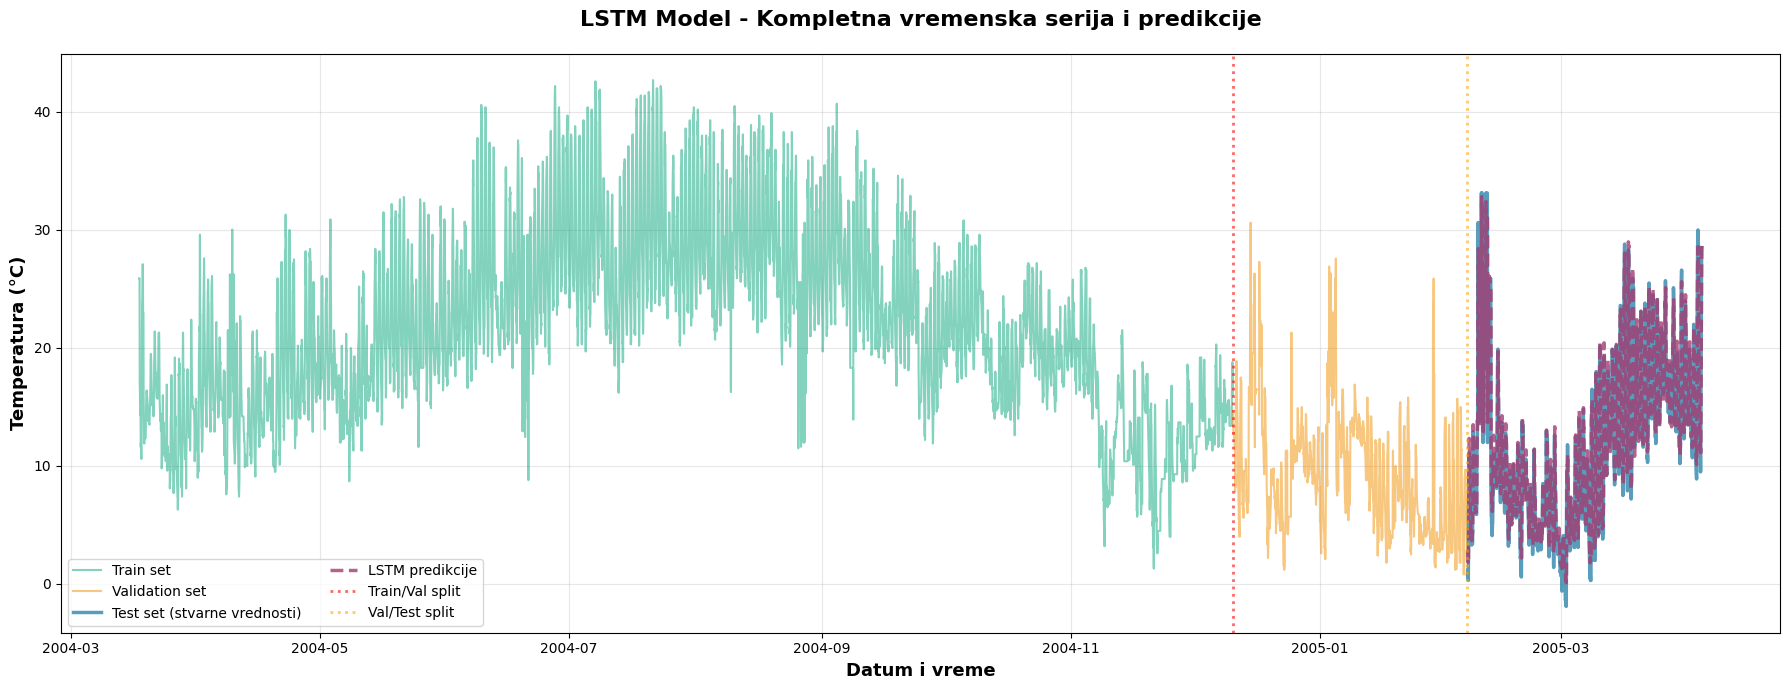

In [166]:
plt.figure(figsize=(18, 7))

# Train
train_dates = timeseries_lstm.index[SEQ_LENGTH:train_end_idx]
plt.plot(train_dates, 
         timeseries_lstm.values[SEQ_LENGTH:train_end_idx],
         label='Train set', linewidth=1.5, color='#06A77D', alpha=0.5)

# Validation
val_dates = timeseries_lstm.index[train_end_idx:val_end_idx]
plt.plot(val_dates,
         timeseries_lstm.values[train_end_idx:val_end_idx],
         label='Validation set', linewidth=1.5, color='#F18F01', alpha=0.5)

# Test - stvarne vrednosti
plt.plot(test_dates, y_test_actual,
         label='Test set (stvarne vrednosti)', linewidth=2.5, color='#2E86AB', alpha=0.8)

# Test - predikcije
plt.plot(test_dates, y_pred,
         label='LSTM predikcije', linewidth=2.5, color='#A23B72', linestyle='--', alpha=0.8)

# Vertikalne linije
plt.axvline(x=train_dates[-1], color='red', linestyle=':', linewidth=2, alpha=0.6, label='Train/Val split')
plt.axvline(x=val_dates[-1], color='orange', linestyle=':', linewidth=2, alpha=0.6, label='Val/Test split')

# Stilizovanje
plt.title('LSTM Model - Kompletna vremenska serija i predikcije', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Datum i vreme', fontsize=13, fontweight='bold')
plt.ylabel('Temperatura (°C)', fontsize=13, fontweight='bold')
plt.legend(fontsize=10, loc='best', ncol=2)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Zaključak:
- Sa grafika vidimo da LSTM približno prati test seriju
- Ali opet iz metrika vidimo da model nije najbolji
- Svakako je bolji od SARIMAX modela, koji nije mogao da razume ove podatke
- Ovo je NN sa 5 layera, jednim ulaznim, jednim izlaznim i 3 skrivena sloja
- Od 3 skrivena sloja, najbitniji je LSTM sloj, on je jezgro našeg NN-a
- LSTM ima 64 "memorijska kanala" u našem slučaju, može imati i više ali je rizik da se desi overfitting
- Input layer, nam govori samo koliko koraka gledamo u nazad i koliki je broj varijabli po koraku
- Dropout nam pomaže da nam se model ne uhvati za šum u podacima, i takodje nasumično gasi, u ovom slučaju 20% neurona, kako bi sprečio ovo prvo
- Koristimo RELU, kao aktivacionu funkciju
- Za output sloj, od FORECAST_HORIZON-a nam zavisi koliko dana hoćemo da predvidimo
- Nema aktivacija u tom sloju